# Análisis de Exploración de  (EDA)

### Descripción del Dataset: Adult (Census Income)

**Contexto y Objetivo General**

El dataset "Adult", también conocido como "Census Income", fue extraído por Barry Becker de la base de datos del Censo de Estados Unidos de 1994. El objetivo principal de este conjunto de datos es predecir una variable de interés binaria: **determinar si los ingresos anuales de una persona superan los $50,000 dólares** (`>50K` o `<=50K`) basándose en diversos atributos sociodemográficos y laborales.

**Descripción de las Variables**

El dataset contiene una mezcla de variables categóricas y numéricas (continuas) que definen el perfil de cada individuo.

**Variable Objetivo (Target):**

* **`income`** *(Categórica)*: Clase a predecir. Toma los valores `<=50K` y `>50K`.

**Variables Predictoras (Features):**

*Demográficas y Personales:*

* **`age`** *(Continua)*: Edad del individuo en años.
* **`sex`** *(Categórica)*: Género del individuo (`Male`, `Female`).
* **`race`** *(Categórica)*: Raza del individuo.
* **`native-country`** *(Categórica)*: País de origen o nacimiento.
* **`marital-status`** *(Categórica)*: Estado civil.
* **`relationship`** *(Categórica)*: Relación familiar del individuo respecto al hogar.

*Educación:*

* **`education`** *(Categórica)*: Nivel máximo de educación alcanzado.
* **`education-num`** *(Continua)*: Representación numérica del nivel educativo.

*Laborales:*

* **`workclass`** *(Categórica)*: Sector de empleo o clase de trabajo.
* **`occupation`** *(Categórica)*: Ocupación o rol específico en el trabajo.
* **`hours-per-week`** *(Continua)*: Cantidad de horas que el individuo trabaja por semana.

*Financieras y Estadísticas:*

* **`capital-gain`** *(Continua)*: Ganancias de capital registradas.
* **`capital-loss`** *(Continua)*: Pérdidas de capital registradas.
* **`fnlwgt`** *(Continua)*: Estimación ponderada poblacional (peso final).

In [102]:
import numpy as np
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.exceptions import NotFittedError

sns.set_theme(style="whitegrid")

In [103]:
adult = fetch_ucirepo(id=2)
df = adult.data.original
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


In [105]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [106]:
df['education-num'].value_counts()

education-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64

In [107]:
df['education'].value_counts() # Comprobamos que se tratan de los mismos valores

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Se observa que la variable `age` es correcta dado que incluye personas desde los 17 años. Sin embargo, encontramos las siguientes inconsistencias fuertemente peligrosas en el dataset:
-  `capital-gain`  tiene un valor máximo llamativo: **99999**. Se buscará analizar este dato y todos los que se encuentren por encima del Q3.
-  ``hours-per-week``  también cuenta con un valor alto de **99 horas**. También se analizarán los valores por encima del Q3.
- En ambos casos, se realizará boxplots para asegurarnos de su naturaleza y aclarar o descartar si se trata de un outlier.
- `fnlwgt` es un estimador que representa la cantidad de personas. Por ejemplo, si tenemos un valor de 5000, quiere decir que existen 4999 personas similares demográficamente.
- `education-num` es una representación numérica de la variable `education`.

---

## Valores únicos por variable

In [108]:
for str_col in df.select_dtypes(include=['str']):
    print('===============================')
    print(df[str_col].value_counts(dropna=False, normalize=True)*100)
    print('===============================')
    print('')

workclass
Private             69.419762
Self-emp-not-inc     7.907129
Local-gov            6.420703
State-gov            4.055935
?                    3.759060
Self-emp-inc         3.470374
Federal-gov          2.931903
NaN                  1.971664
Without-pay          0.042996
Never-worked         0.020474
Name: proportion, dtype: float64

education
HS-grad         32.316449
Some-college    22.271815
Bachelors       16.430531
Masters          5.439990
Assoc-voc        4.219729
11th             3.709922
Assoc-acdm       3.277917
10th             2.843864
7th-8th          1.955284
Prof-school      1.707547
9th              1.547848
12th             1.345154
Doctorate        1.216166
5th-6th          1.042136
1st-4th          0.505712
Preschool        0.169936
Name: proportion, dtype: float64

marital-status
Married-civ-spouse       45.819172
Never-married            32.998239
Divorced                 13.580525
Separated                 3.132550
Widowed                   3.107981
Marrie

Observamos que algunas variables tienen NAs por defecto y otros registrados como `?`. Por lo cual, optaremos por reemplazar todos los `?` por NAs para un manejo más ideal de los datos.
Además, se tomará en cuenta que `South` signficia `Corea del Sur` y Hong es `Hong Kong`. También observamos que hay variables como la nacionalidad que tienen categorías con baja representación, lo cual podemos tomar en cuenta para agrupar categorías.

---

In [109]:
df.replace('?', np.nan, inplace=True)                   # Realizamos el reemplazo de los '?' por NaN y la correcta asignación de valores
df['native-country'] = df['native-country'].replace({
    'South': 'South-Korea',
    'Hong': 'Hong-Kong'
})
df.isna().sum().sort_values(ascending=False)

occupation        2809
workclass         2799
native-country     857
fnlwgt               0
education            0
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
race                 0
capital-gain         0
capital-loss         0
hours-per-week       0
income               0
dtype: int64

In [110]:
df['native-country'].unique() # Encontramos que el cambio se realizó correctamente en la asignación de valores.

<ArrowStringArray>
[             'United-States',                       'Cuba',
                    'Jamaica',                      'India',
                          nan,                     'Mexico',
                'South-Korea',                'Puerto-Rico',
                   'Honduras',                    'England',
                     'Canada',                    'Germany',
                       'Iran',                'Philippines',
                      'Italy',                     'Poland',
                   'Columbia',                   'Cambodia',
                   'Thailand',                    'Ecuador',
                       'Laos',                     'Taiwan',
                      'Haiti',                   'Portugal',
         'Dominican-Republic',                'El-Salvador',
                     'France',                  'Guatemala',
                      'China',                      'Japan',
                 'Yugoslavia',                       'Peru',
 'Out

In [111]:
df['income'].value_counts(normalize=True)*100

income
<=50K     50.612178
<=50K.    25.459645
>50K      16.053806
>50K.      7.874370
Name: proportion, dtype: float64

## Relación del target

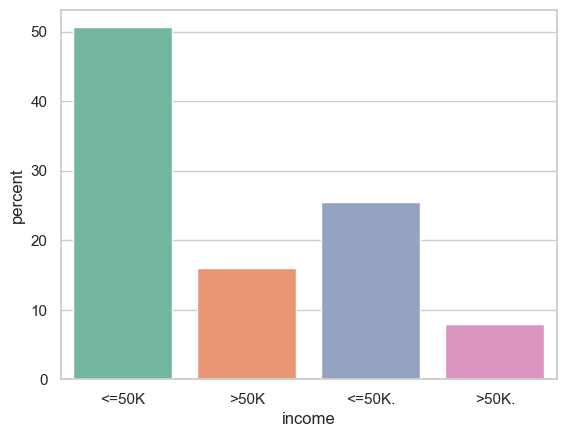

In [112]:
sns.countplot(x='income', hue = 'income', data = df, palette="Set2", stat = 'percent') # Problemas de escritura
plt.show()

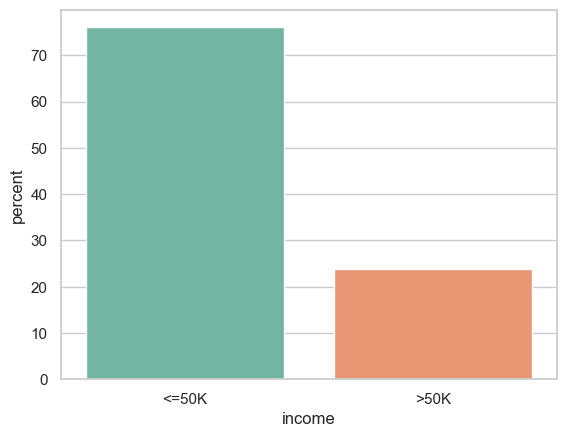

In [113]:
df['income'] = df['income'].str.strip()

df['income'] = df['income'].replace({ # Realizamos los reemplazos en el target para corregir los problemas de escritura
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})
sns.countplot(x='income', hue = 'income', data = df, palette="Set2", stat = 'percent')
plt.show()

Observamos que existe un desbalance cercano a 75/25, lo cual podría requerir del uso de técnicas de balanceo de datos y/o métricas que permitan medir objetivamente los resultados obtenidos.

---

## Distribución de las variables

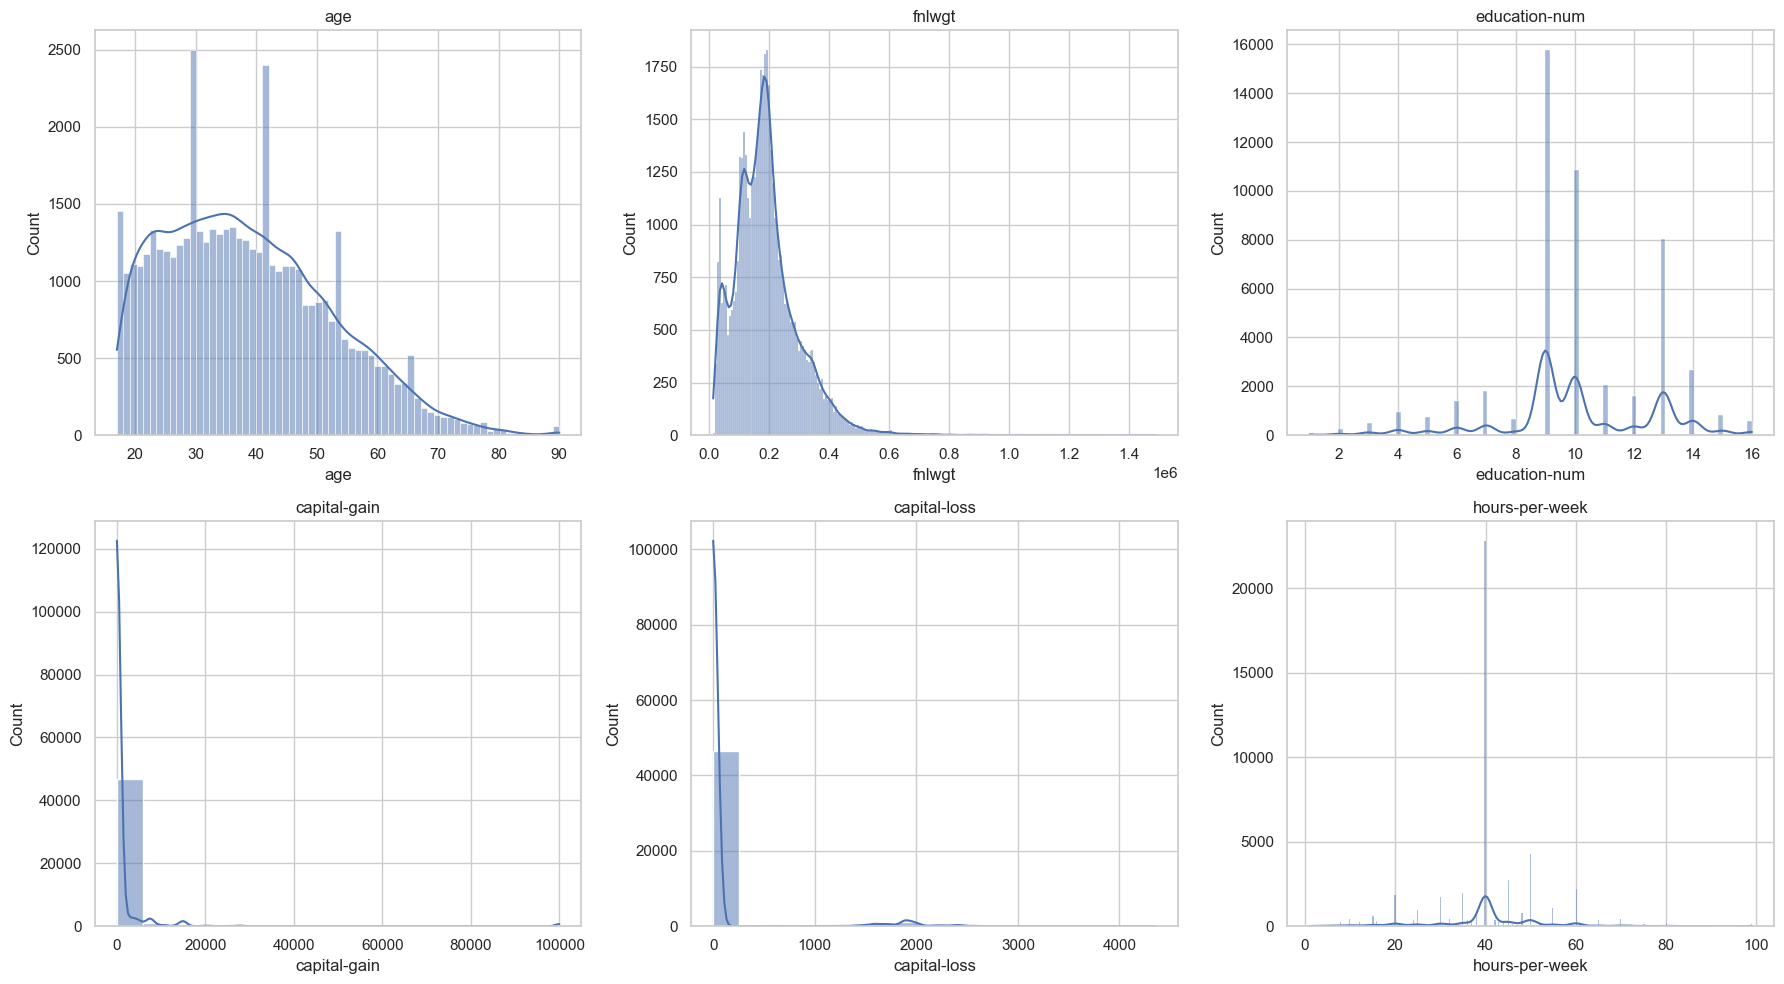

In [114]:
save_dir = Path("plots/distribucion_variables")
save_dir.mkdir(parents=True, exist_ok=True)

num_cols = df.select_dtypes(include=['float', 'int']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for col, ax in zip(num_cols, axes):
    sns.histplot(x=col,
                 data=df,
                 kde=True,
                 ax=ax)
    ax.set_title(col)

    fig_ind = plt.figure(figsize=(16, 9))
    sns.histplot(x=col, data=df, kde=True)
    plt.title(col)
    plt.tight_layout()
    fig_ind.savefig(save_dir / f"{col}_histograma.png", dpi=400)
    plt.close(fig_ind)

fig.tight_layout()
plt.show()


Observamos los siguientes patrones:
- La edad muestra una asimetría positiva, lo cual que la mayoría de personas tienen entre 20 a 50 años.
- La variable `fnlwgt` es una variable meramente demográfica y no tiene importancia dentro del análisis actual. Aún asi, podemos describir que la mayoría de perfiles son coumunes.
- La variable `education_num` es una clara representación de un barplot de la variable `education`.
- Tanto en la variable `capital-gain` y `capital-loss`, observamos que la mayoría de personas suelen tener valores pequeños. También se puede mencionar que, de ser necesario, aplicar una transformación logarítmica o Box-Cox sería lo ideal, específicamente `log1p` dado que tiene valores desde 0.
- La variable `hours-per-week` muestra una similitud a una campana de Gauss. Sin embargo, preocupa que existan adultos con más de 80 horas laborables por semana.

---

## Distribución numéricas de las variables según el ingreso

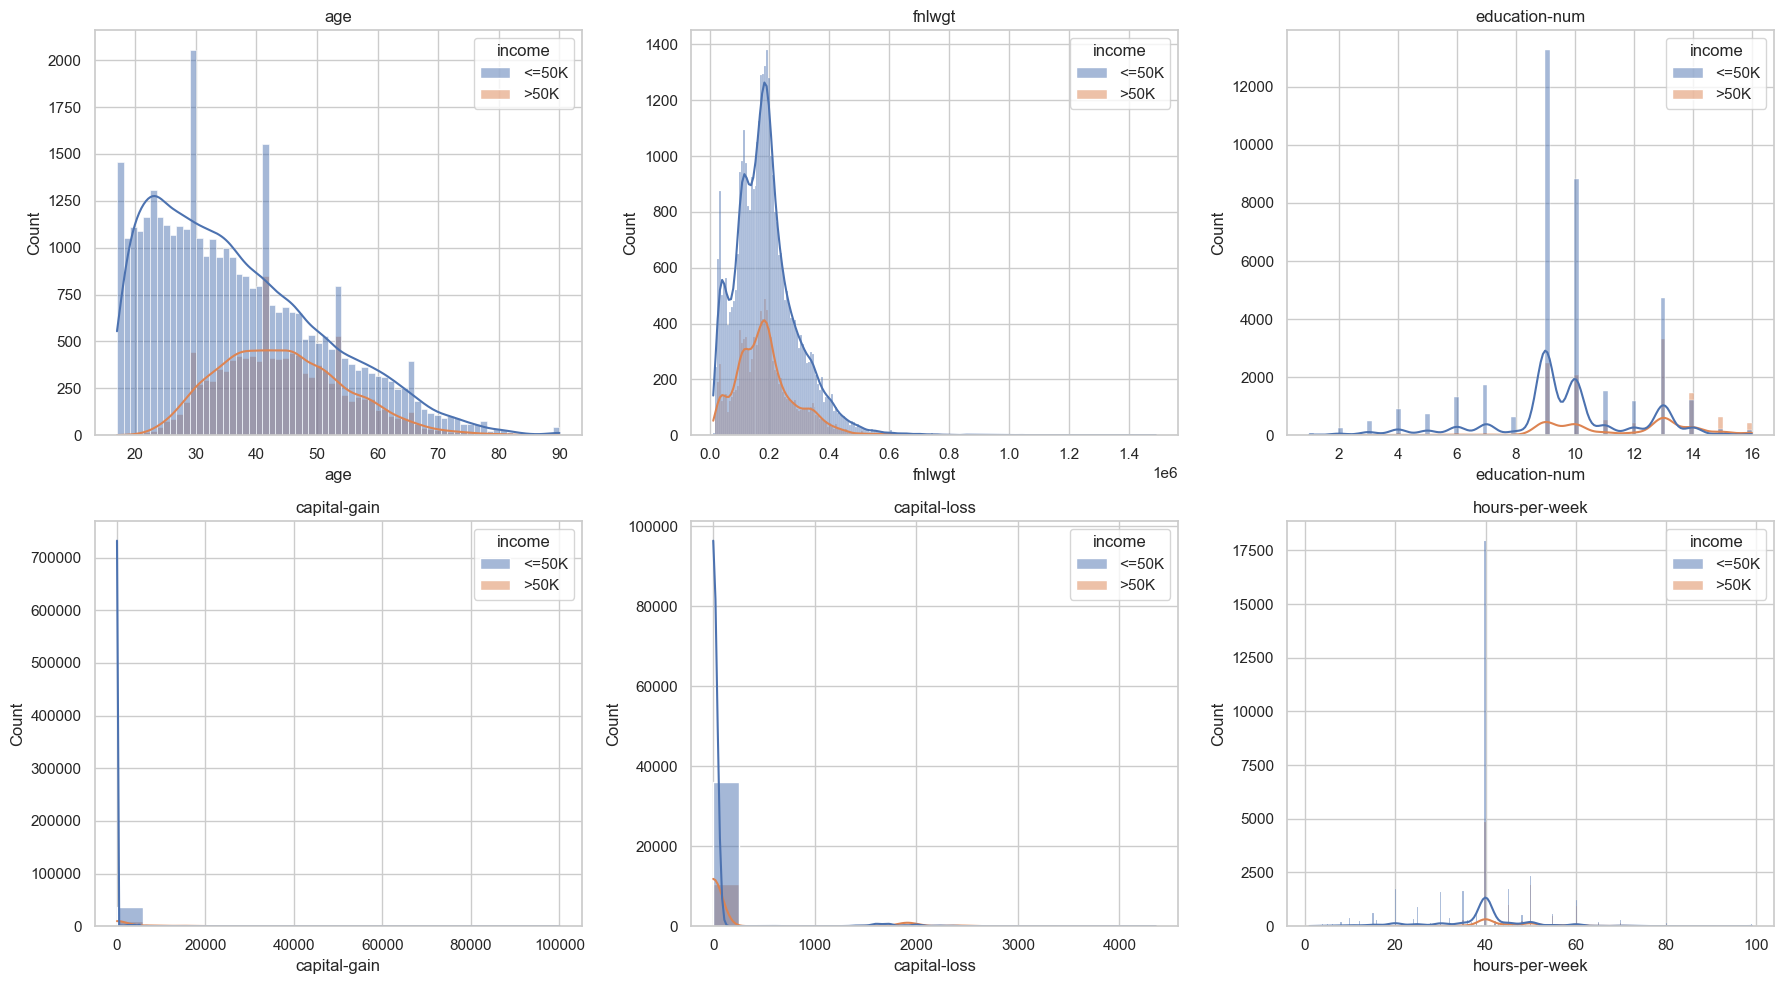

In [115]:
save_dir = Path("plots/distribucion_variables")
save_dir.mkdir(parents=True, exist_ok=True)

num_cols = df.select_dtypes(include=['float', 'int']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for col, ax in zip(num_cols, axes):
    sns.histplot(x=col,
                 data=df,
                 kde=True,
                 ax=ax,
                 hue='income')
    ax.set_title(col)

    fig_ind = plt.figure(figsize=(16, 9))
    sns.histplot(x=col, data=df, kde=True, hue = 'income')
    plt.title(col)
    plt.tight_layout()
    fig_ind.savefig(save_dir / f"{col}_histograma_por_ingreso.png", dpi=400)
    plt.close(fig_ind)

fig.tight_layout()
plt.show()


Observamos los siguientes comportamientos:
- Las personas con ingresos menores de $50 K suelen ser personas más jovenes, a diferencia de las personas con ingresos mayores que están entre los 35 a 50 años aproximadamente.
- Las otras variables tienen una distribución similar en ambos casos. 

---

## Boxplots de las variables numéricas (Detección de outliers)

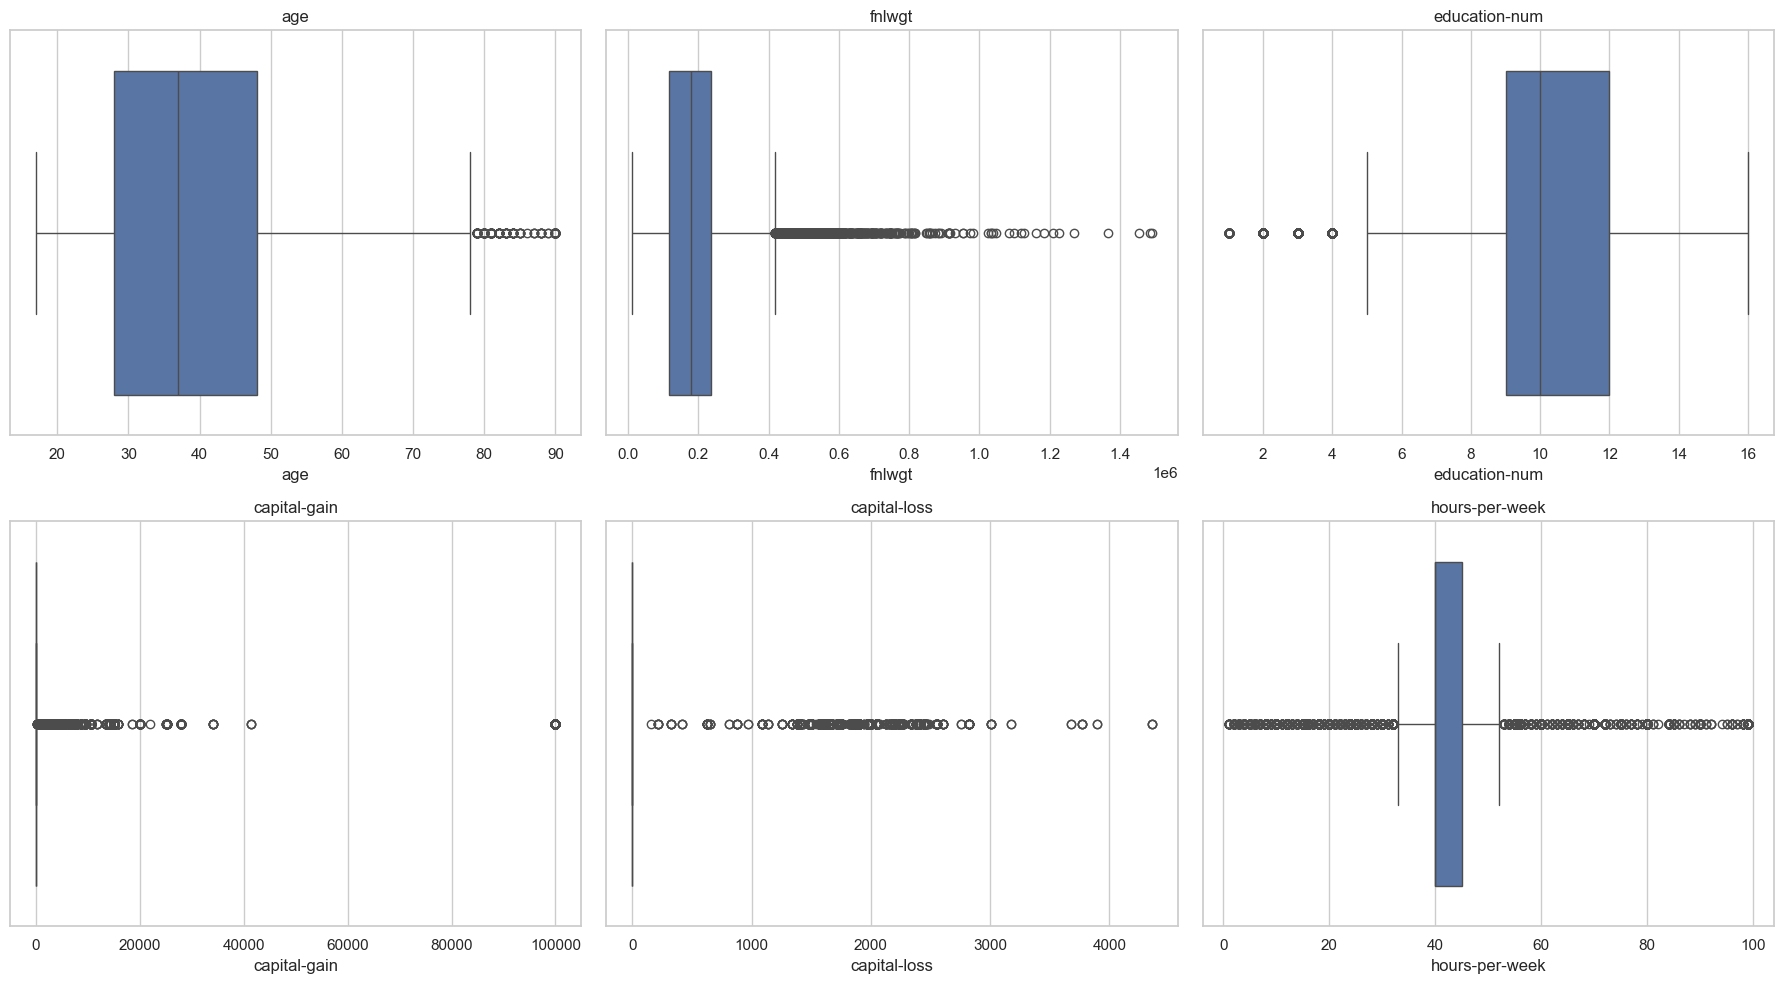

In [116]:
save_dir = Path("plots/boxplots_variables")
save_dir.mkdir(parents=True, exist_ok=True)

num_cols = df.select_dtypes(include=['float', 'int']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for col, ax in zip(num_cols, axes):
    sns.boxplot(x=col,
                 data=df,
                 ax=ax)
    ax.set_title(col)

    fig_ind = plt.figure(figsize=(16, 9))
    sns.boxplot(x=col, data=df)
    plt.title(col)
    plt.tight_layout()
    fig_ind.savefig(save_dir / f"{col}_boxplot.png", dpi=400)
    plt.close(fig_ind)

fig.tight_layout()
plt.show()


En todos los gráficos observamos outliers, lo cual podría dar problemas para algunos algoritmos de ML.
También comprobamos existen varias personas que tienen más de 60 horas laborables por semana por lo que, eliminar estos registros, podría traer problemas a los modelos y contribuir al overfitting.

---

## Boxplots de las variables numéricas por ingreso

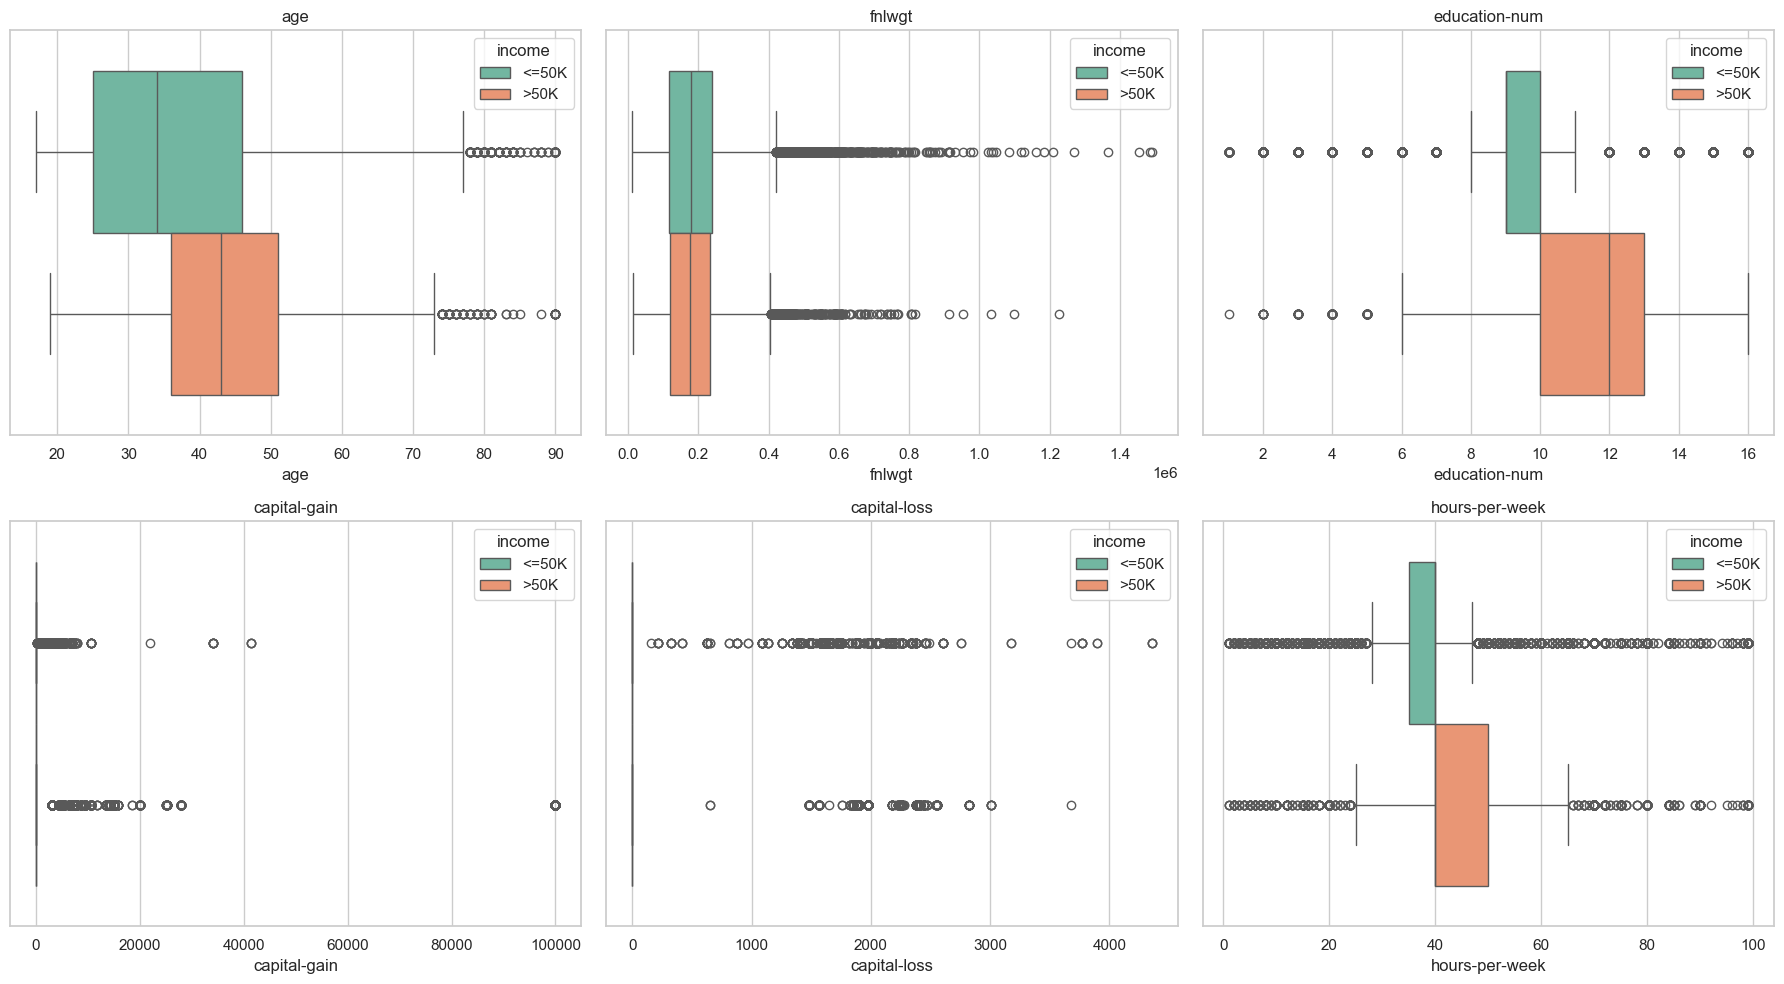

In [117]:
save_dir = Path("plots/boxplots_variables")
save_dir.mkdir(parents=True, exist_ok=True)

num_cols = df.select_dtypes(include=['float', 'int']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for col, ax in zip(num_cols, axes):
    sns.boxplot(x=col,
                 data=df,
                 ax=ax,
                 hue='income',
                 palette='Set2')
    ax.set_title(col)

    fig_ind = plt.figure(figsize=(16, 9))
    sns.boxplot(x=col,
                 data=df,
                 hue='income',
                 palette='Set2')
    plt.title(col)
    plt.tight_layout()
    fig_ind.savefig(save_dir / f"{col}_boxplot_por_ingreso.png", dpi=400)
    plt.close(fig_ind)

fig.tight_layout()
plt.show()


A diferencia de los gráficos anteriores, al segmentar por el target, encontramos varios patrones:
- Al igual que en los histogramas, observamos que las personas más jóvenes tienden a tener menores ingresos.
- Observamos que la mayoría de personas con algún tipo de estudio igual o superior al de HS-Grade cuentan con mayores ingresos respecto a las personas que no han culminado de la secundaria.
- Respecto a `capital-gain` y `capital-loss`, aún no podemos tener un análisis adecuado; por lo tanto, haremos un análisis específico a estas variables.
- La variable `hours-per-week` muestra que el 50% de las personas que ganan más de $ 50K tienen más horas de trabajo respecto al 50% de las personas que ganan menos.

## Análisis bivariado entre variables nominales y target

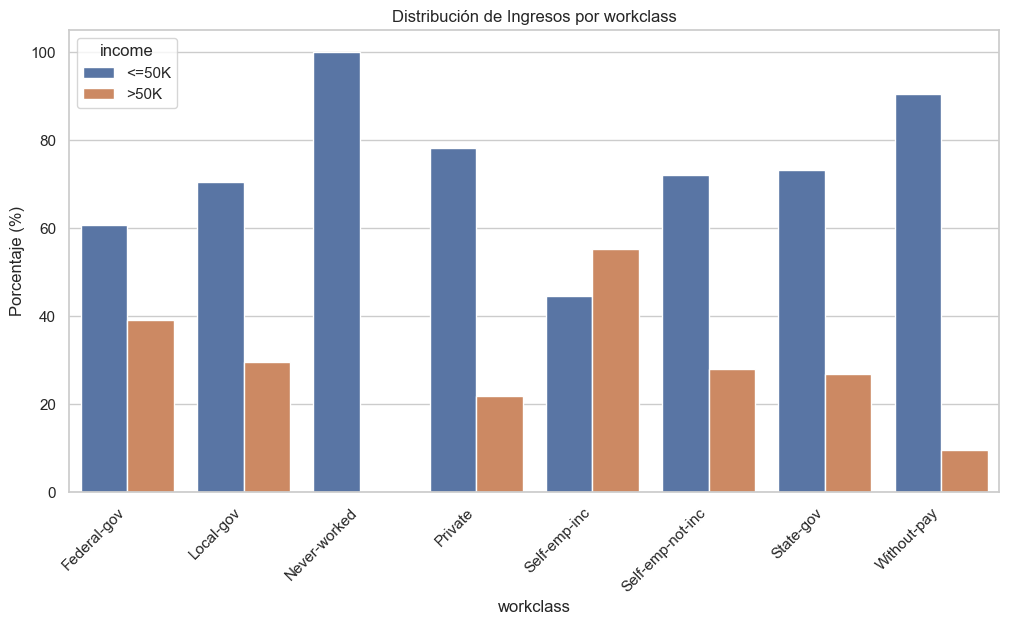

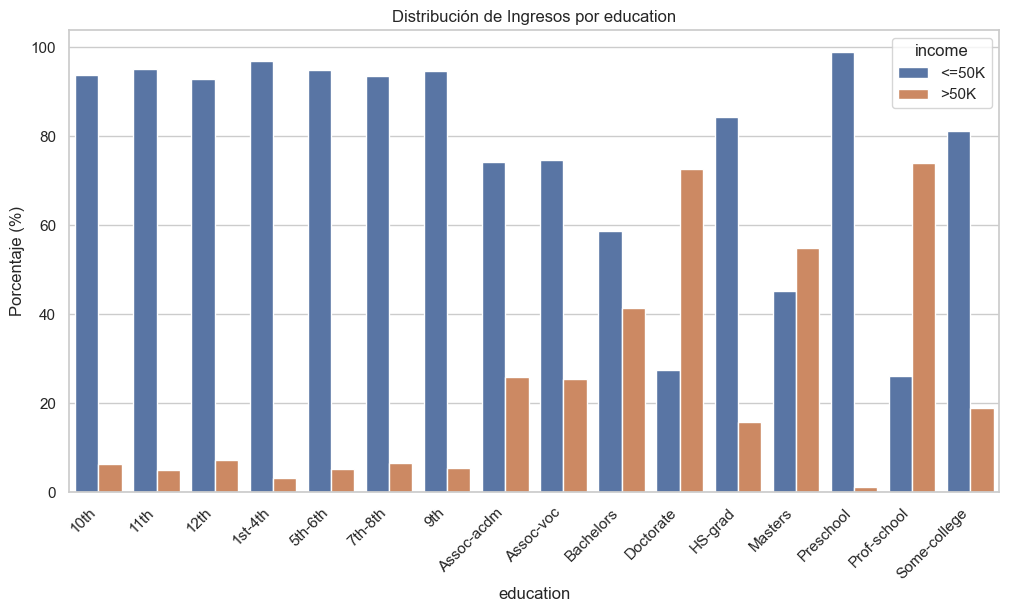

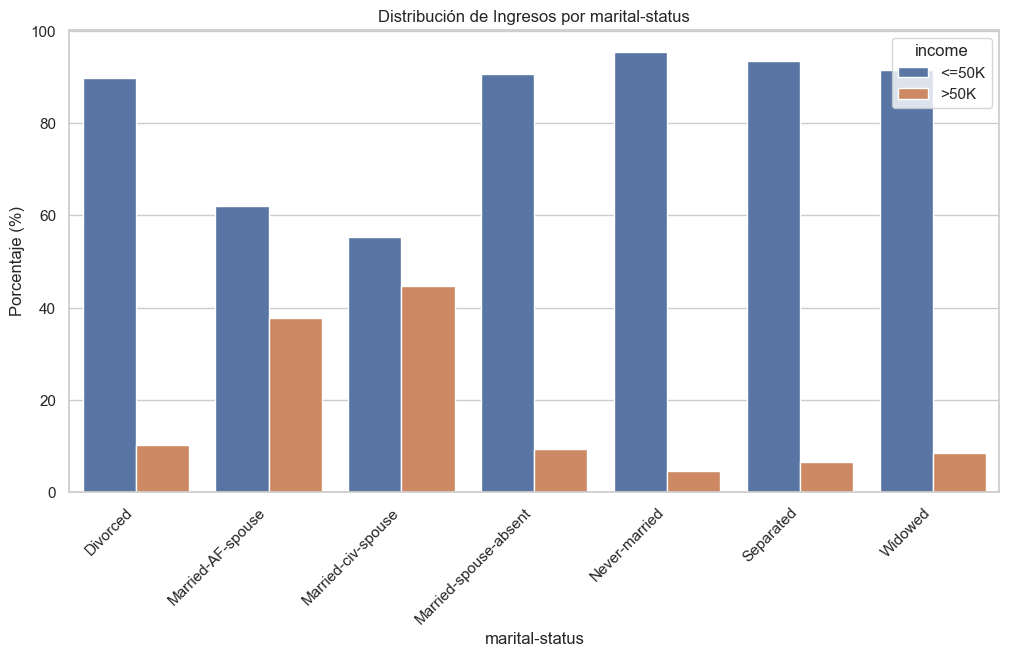

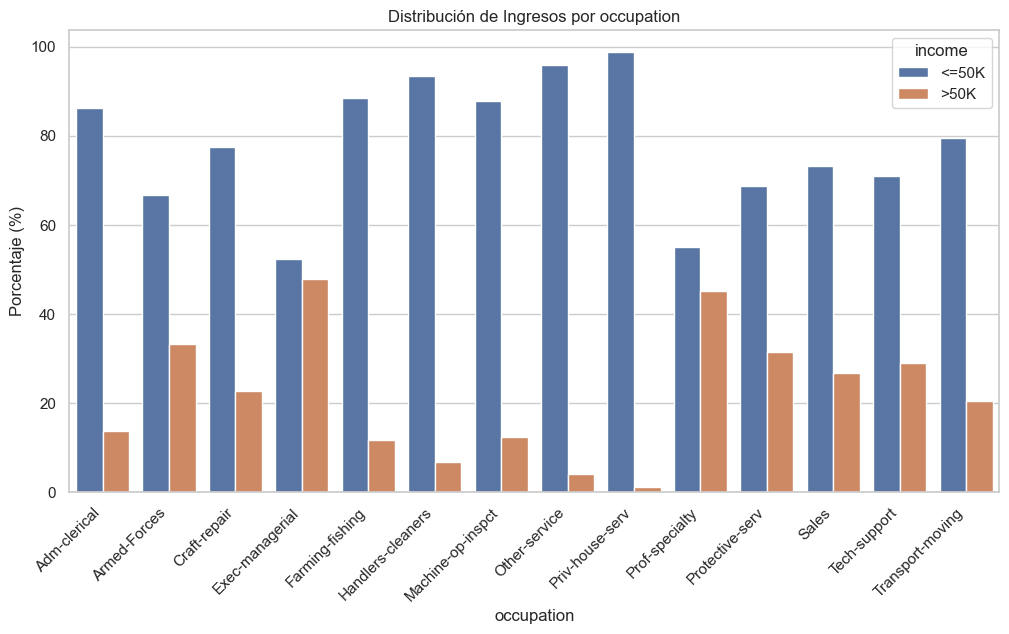

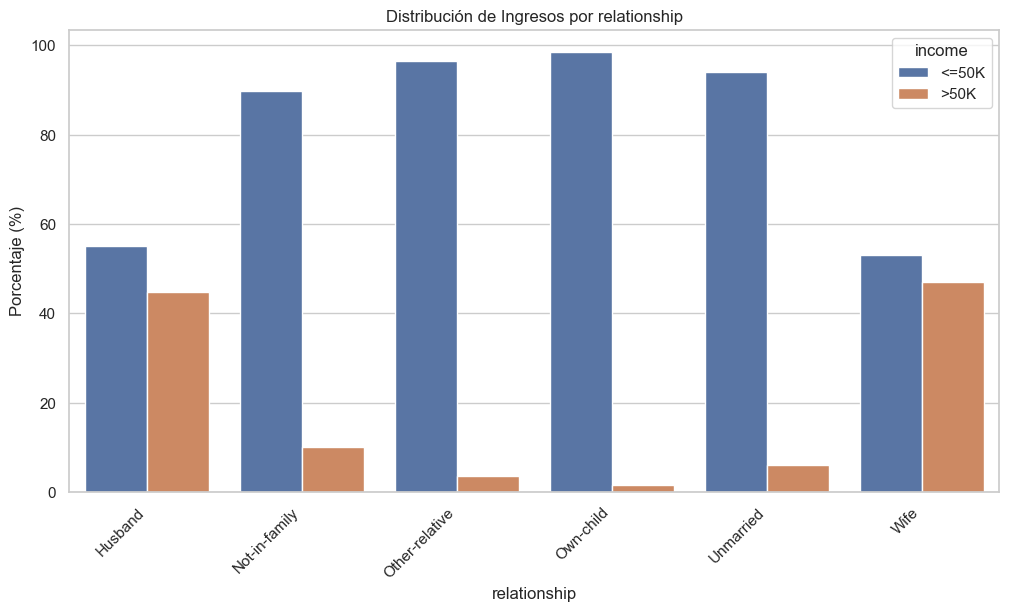

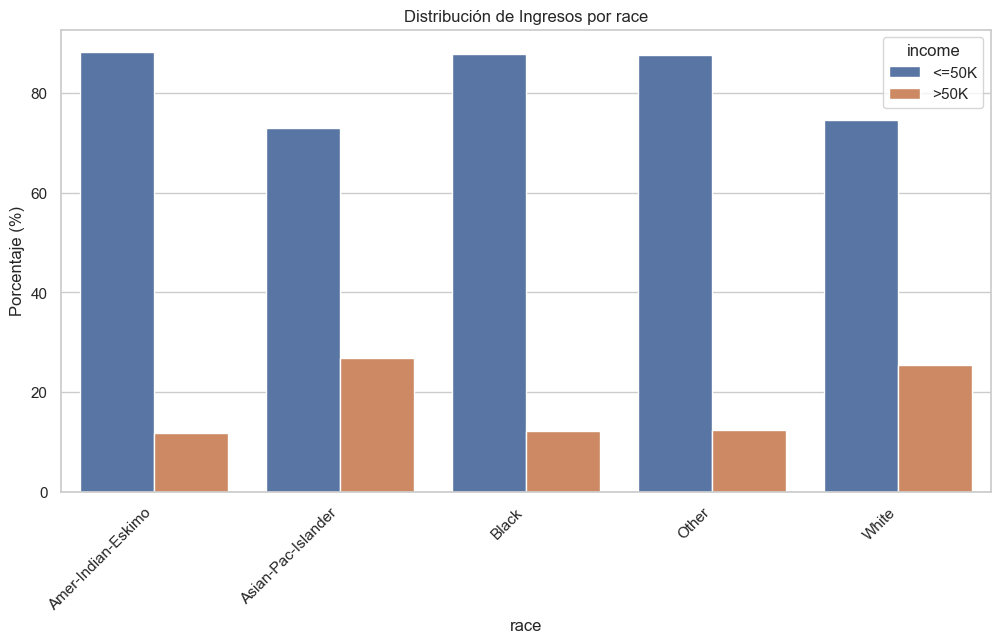

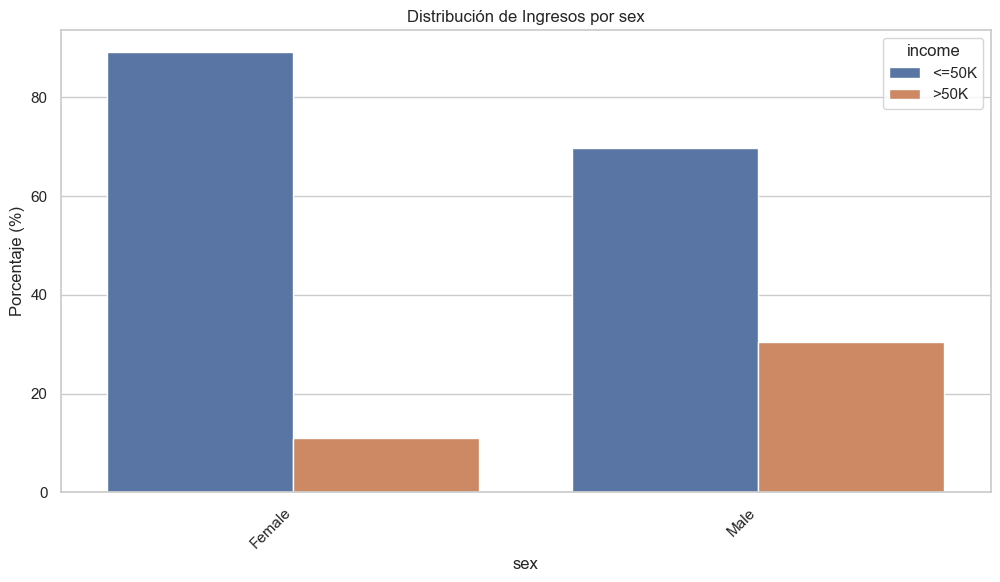

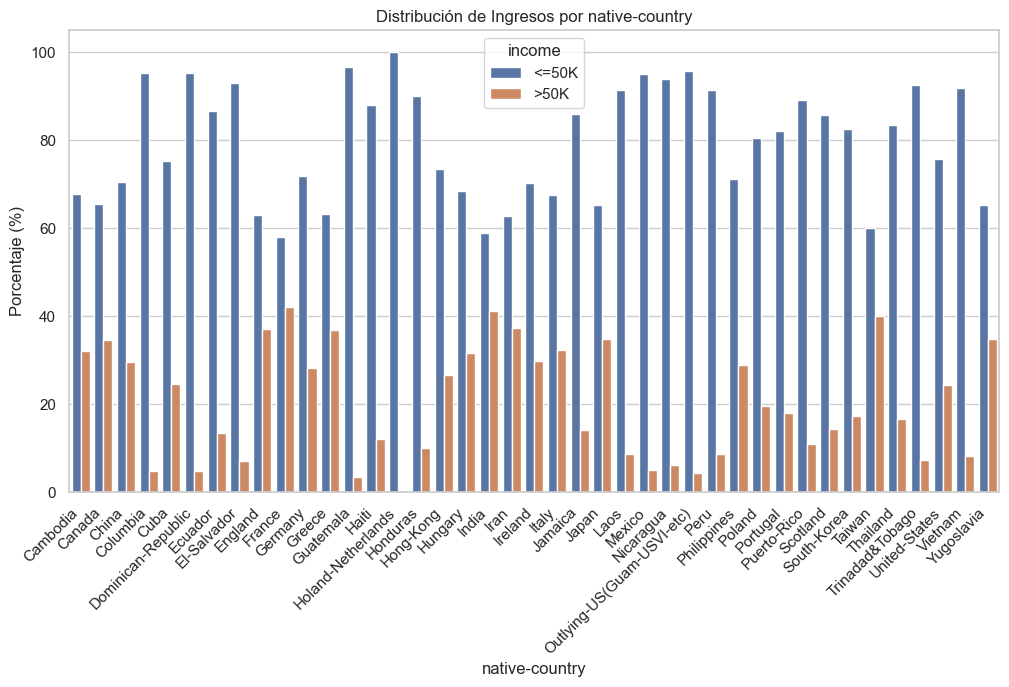

In [118]:
nom_cols = df.select_dtypes(include=['str']).drop(columns=['income'])


for var in nom_cols:
    plt.figure(figsize=(12, 6))

    df_plot = pd.crosstab(df[var], df['income'], normalize='index') * 100

    df_plot = df_plot.stack().reset_index().rename(columns={0: 'percentage'})
    
    sns.barplot(data=df_plot, x=var, y='percentage', hue='income')
    
    plt.title(f'Distribución de Ingresos por {var}')
    plt.ylabel('Porcentaje (%)')
    plt.xticks(rotation=45, ha='right')
    plt.show()

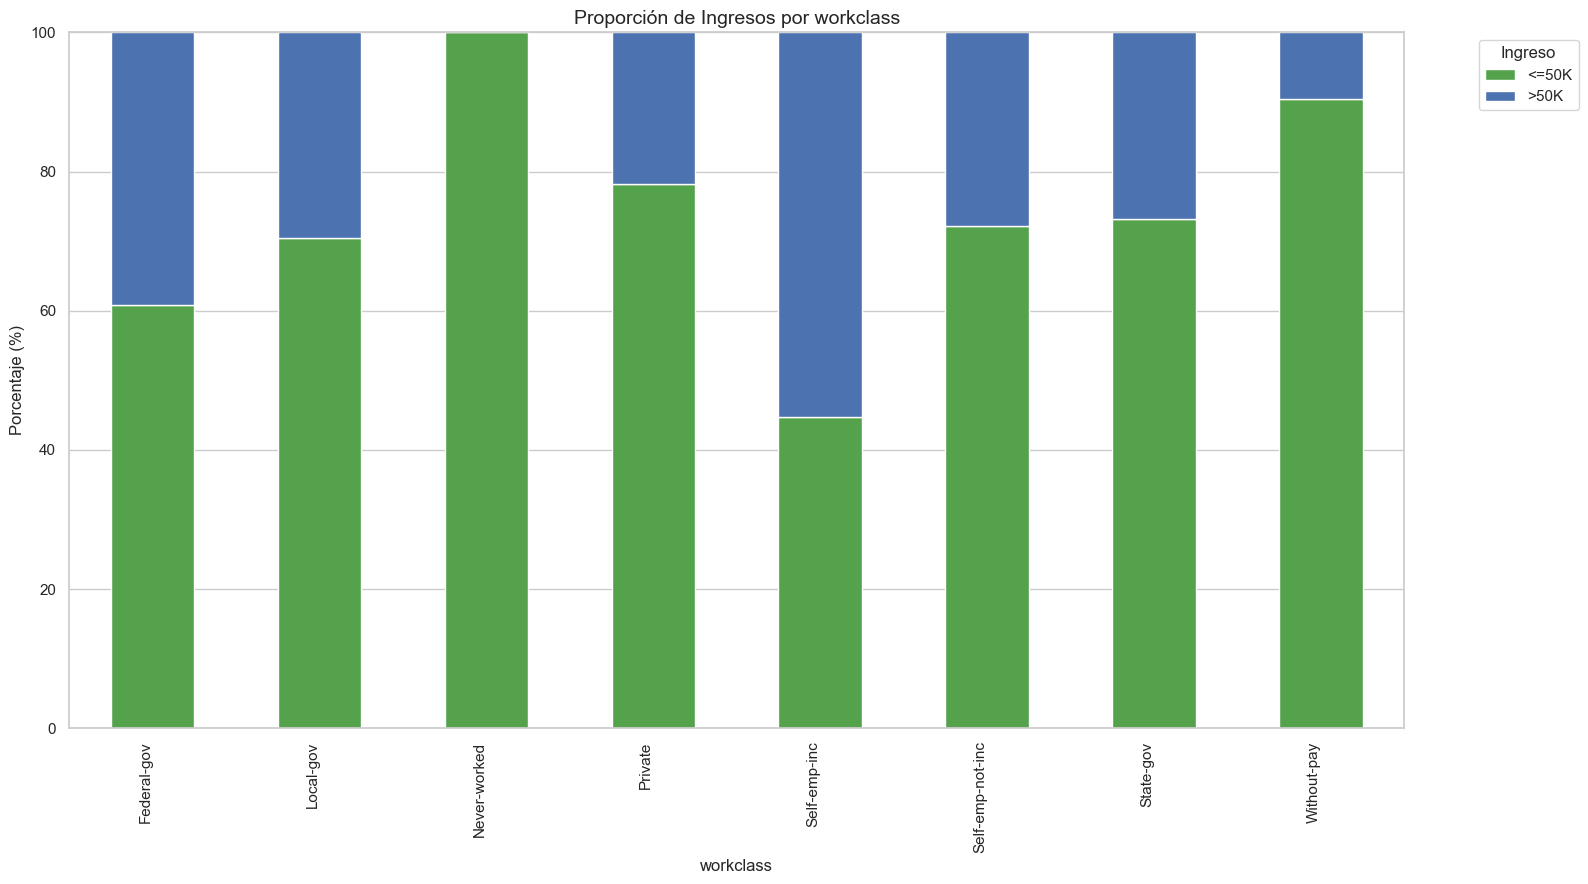

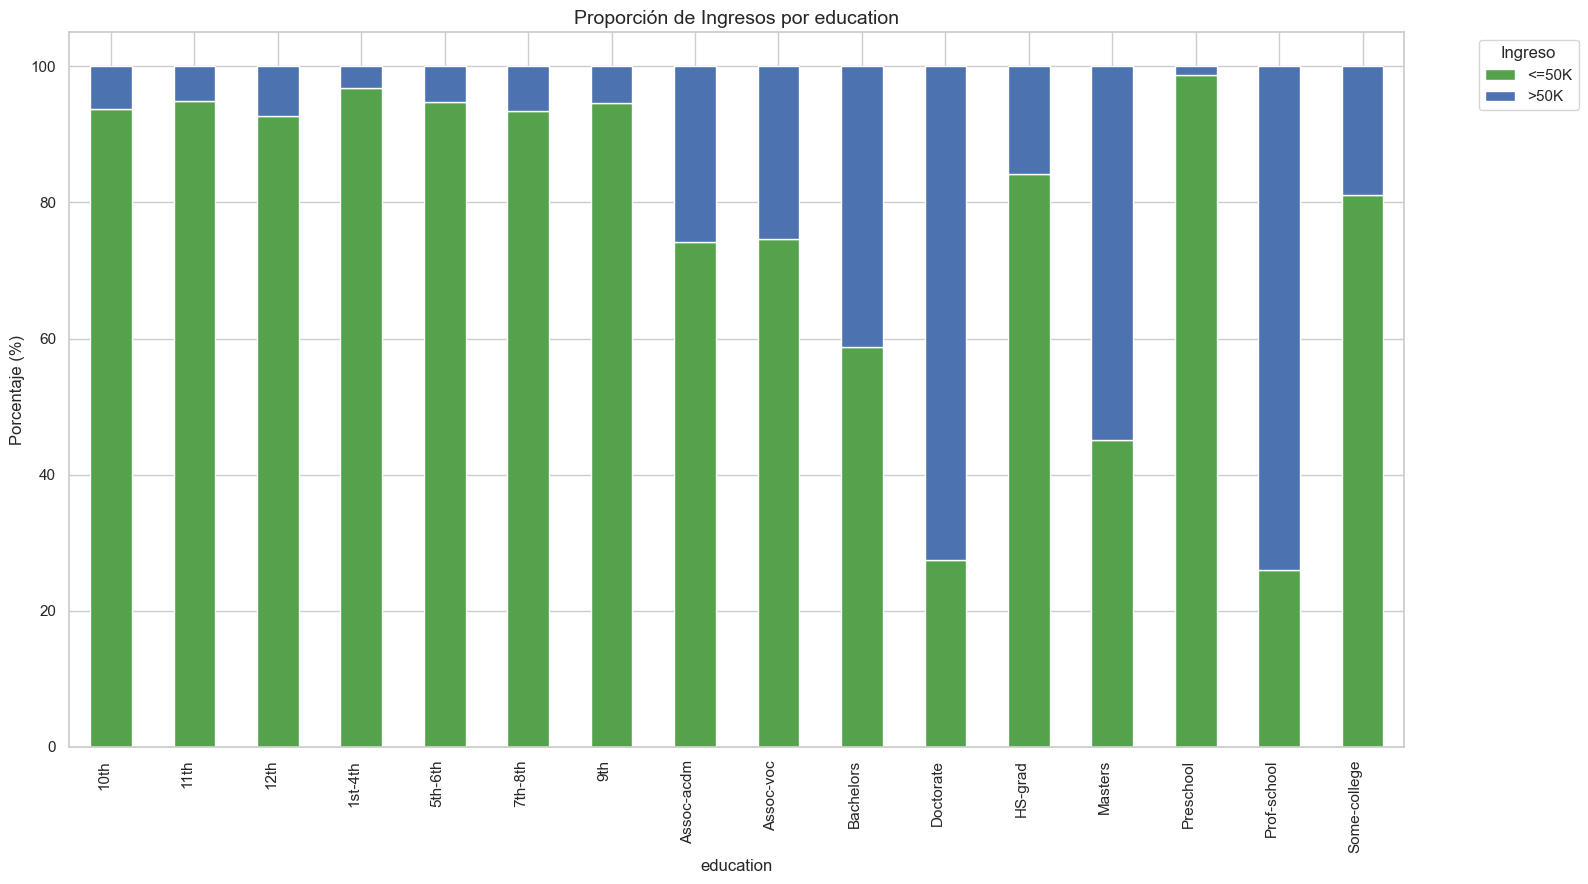

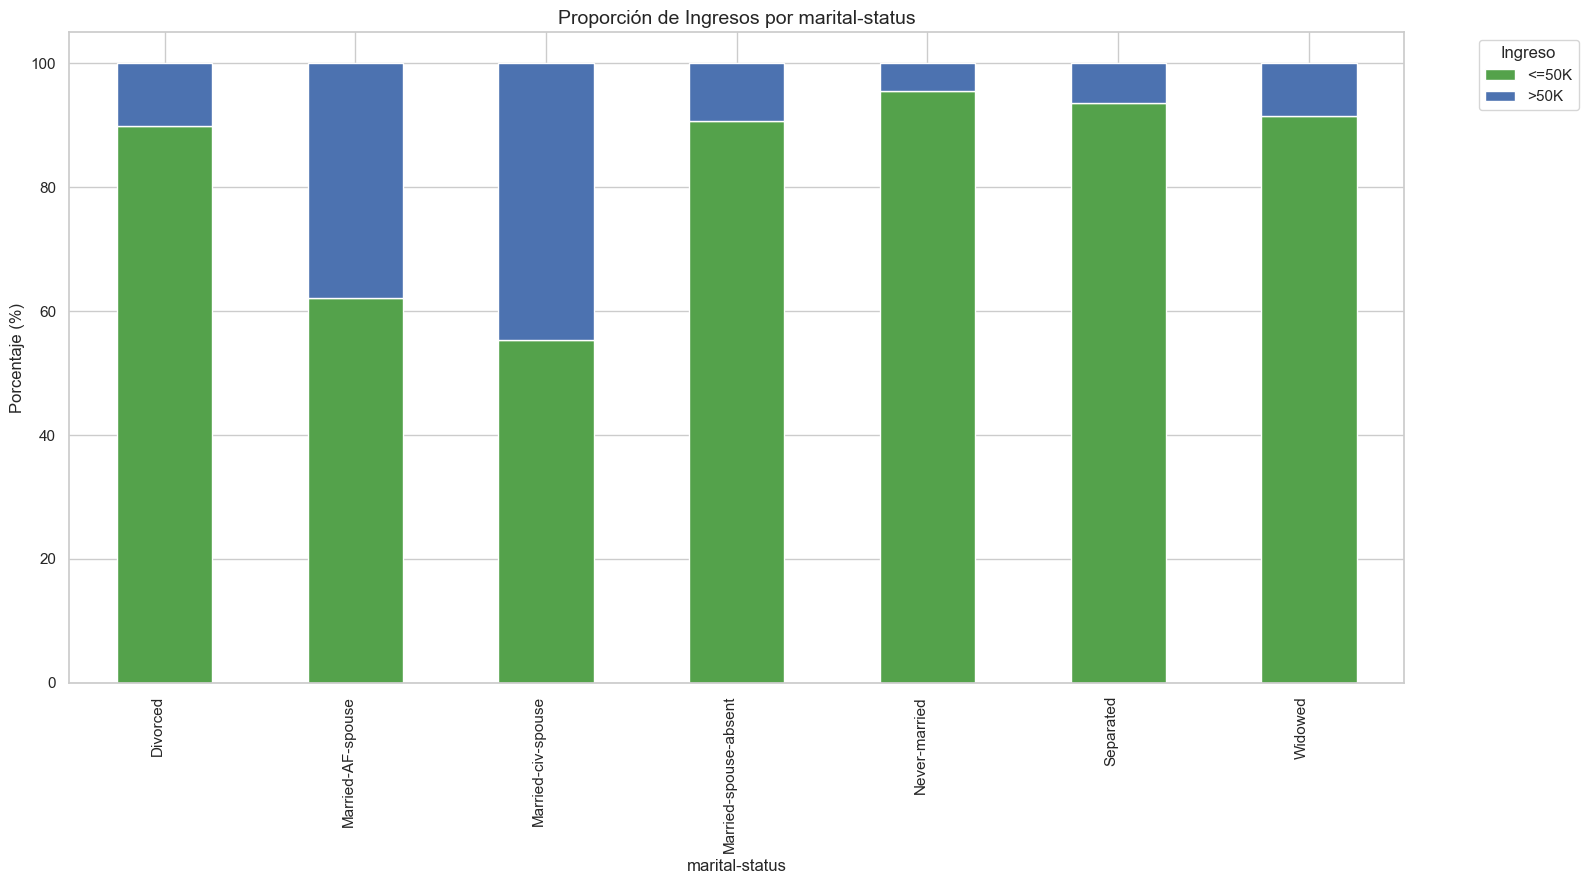

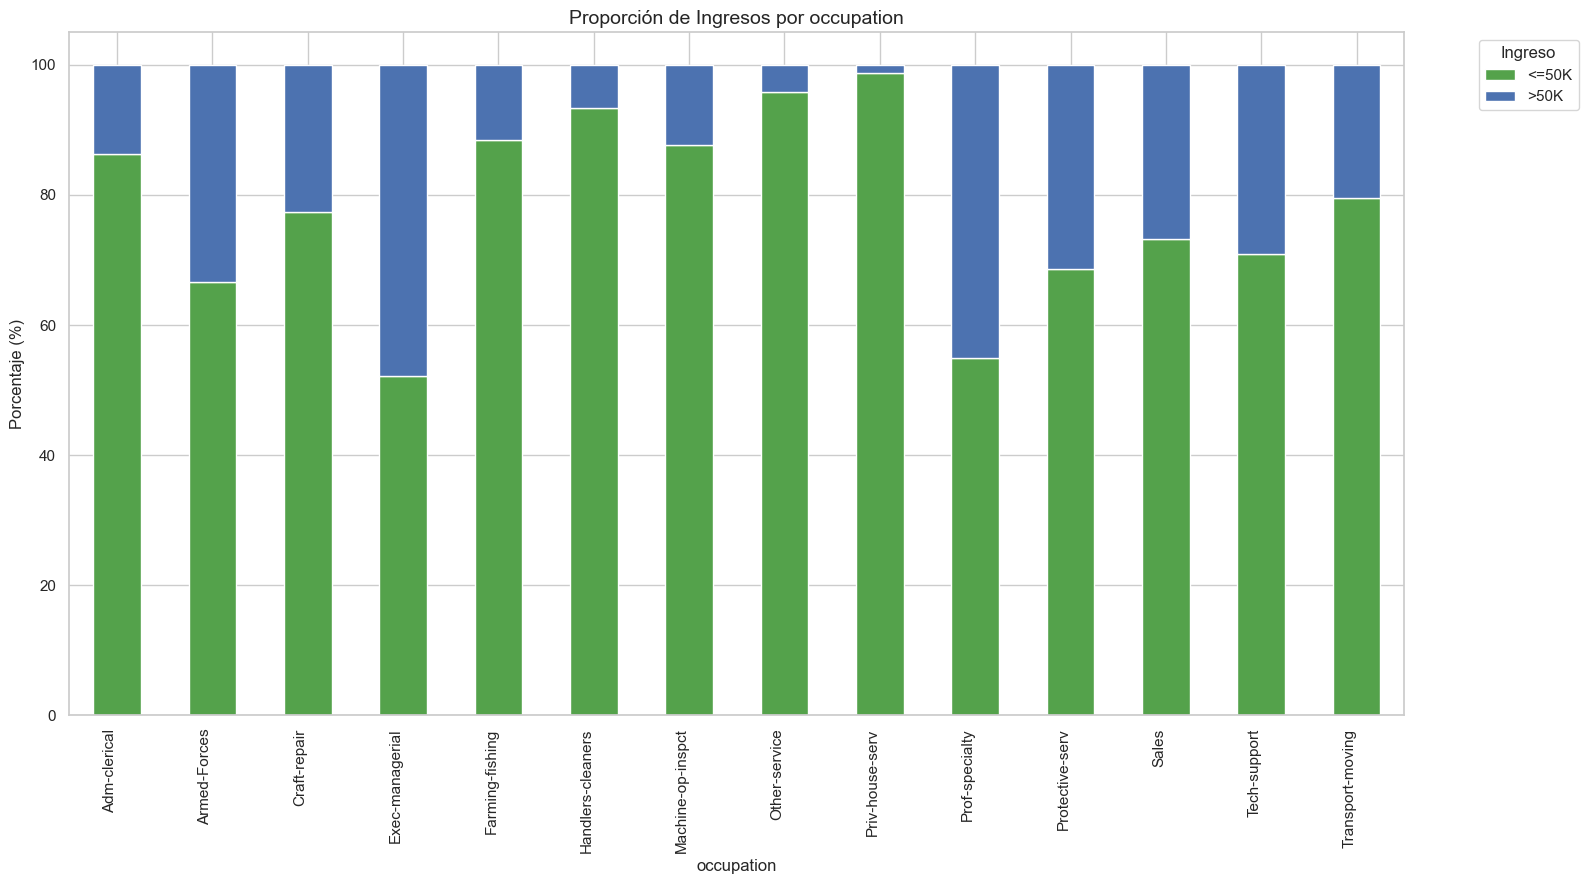

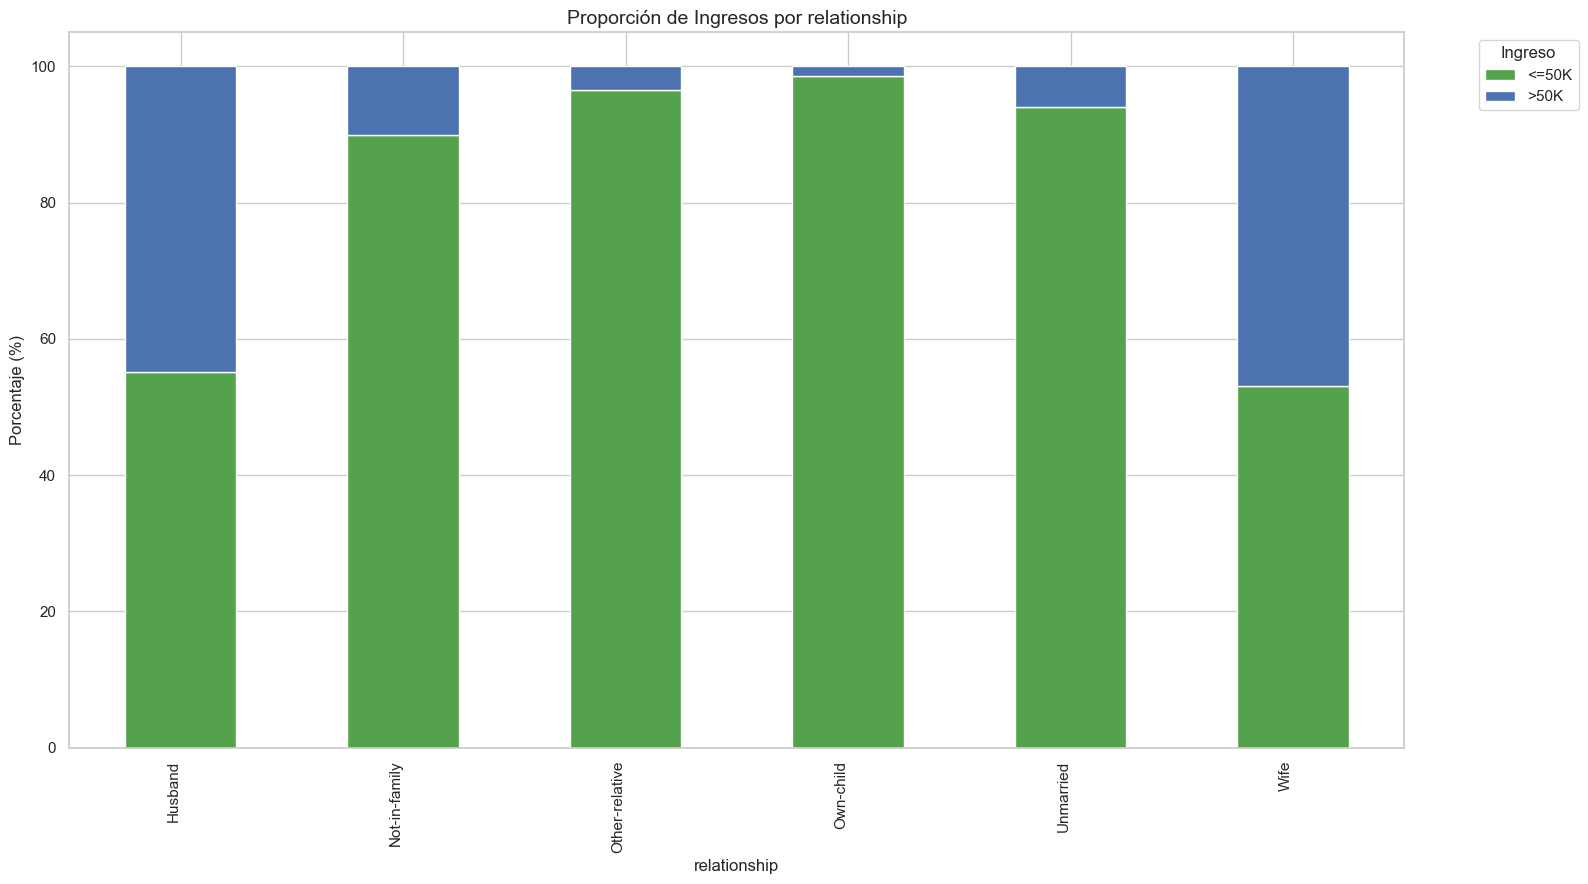

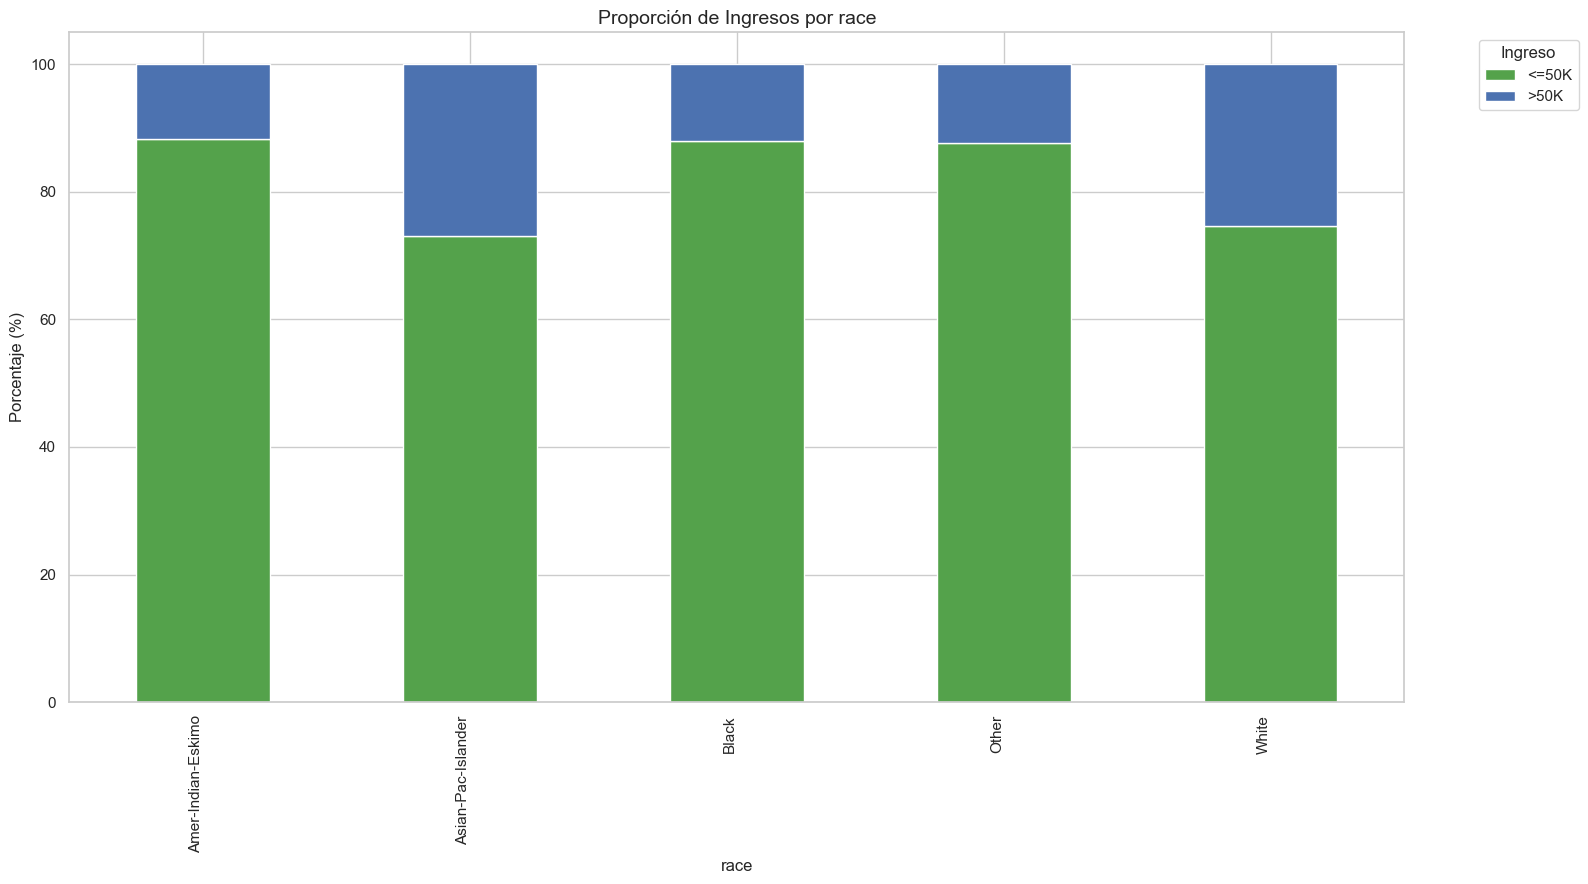

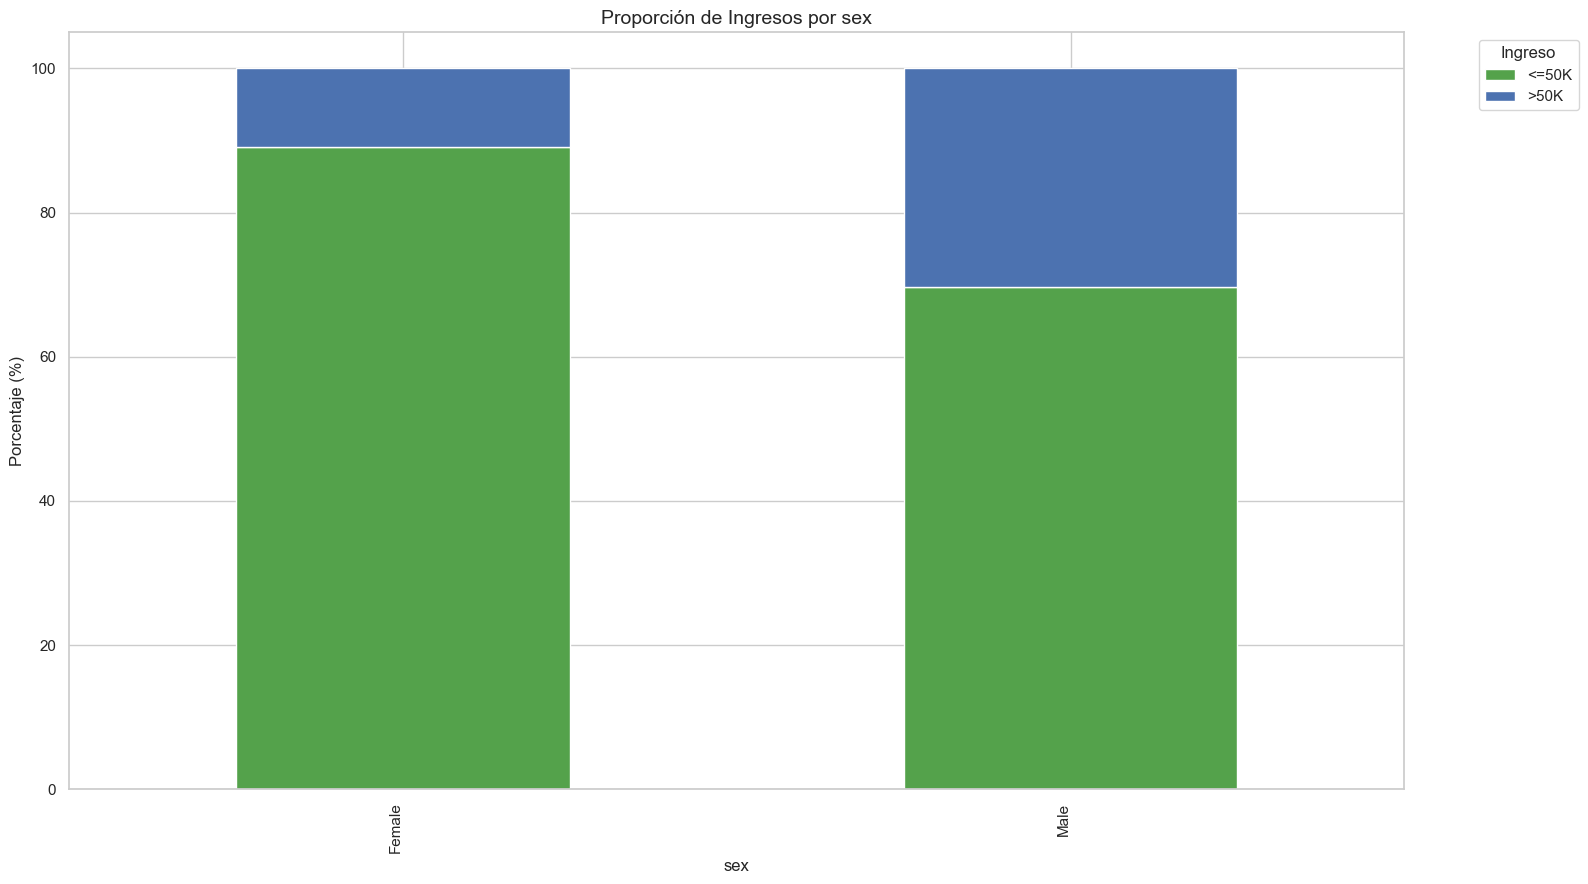

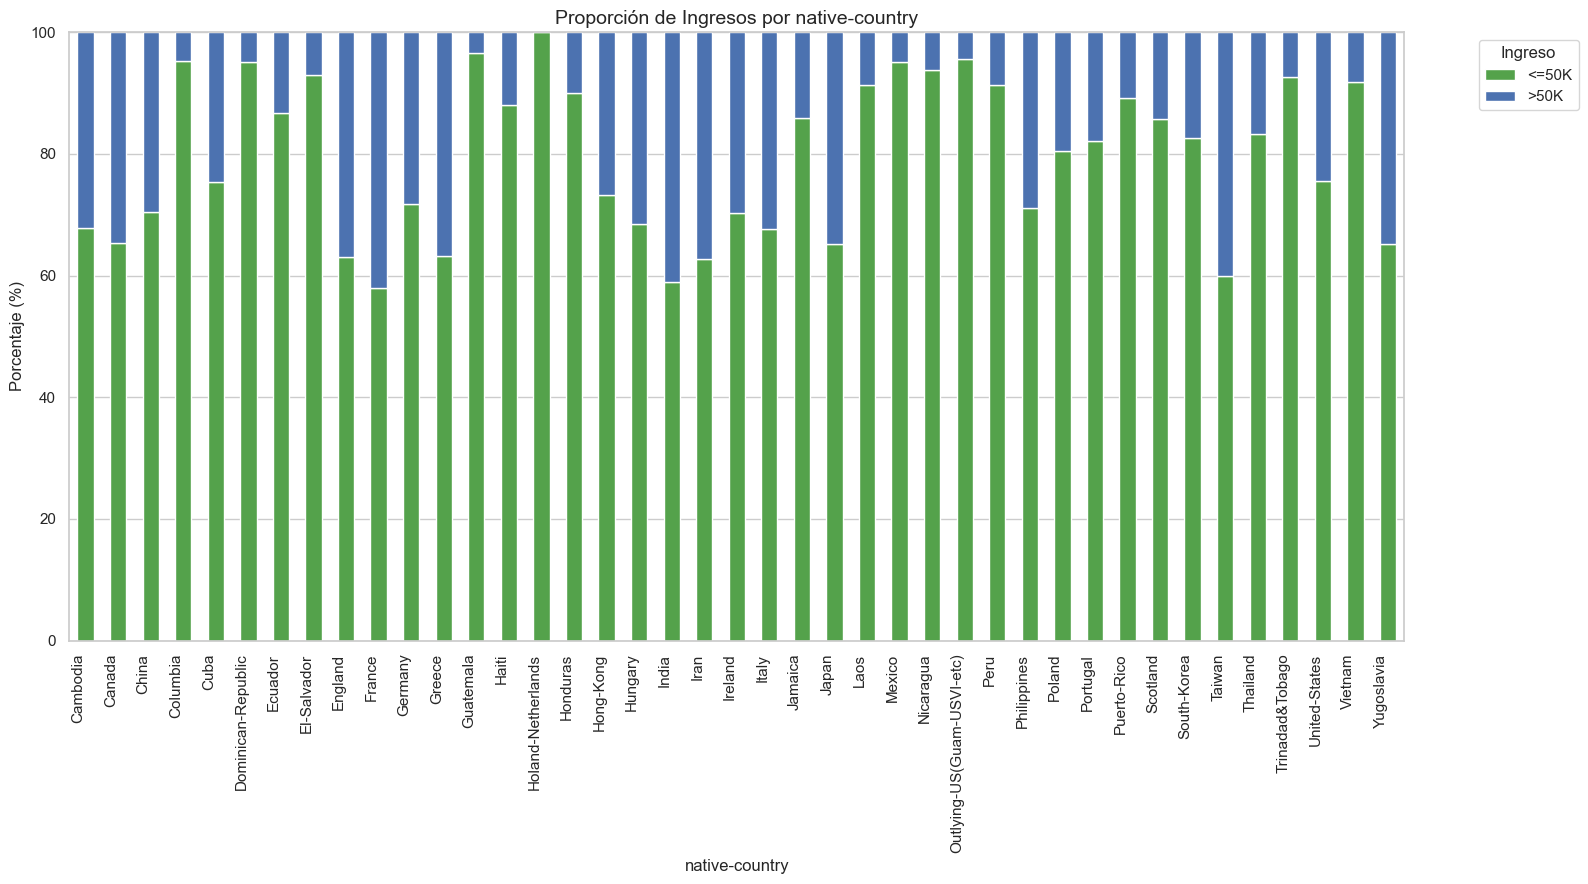

In [119]:
save_dir = Path("plots/proporcion_variables")
save_dir.mkdir(parents=True, exist_ok=True)

for var in nom_cols:
    # Creamos la tabla de contingencia normalizada
    ct = pd.crosstab(df[var], df['income'], normalize='index') * 100
    
    # Graficamos directamente desde el DataFrame de pandas (es más rápido y limpio)
    # kind='bar' + stacked=True genera el gráfico de barras apiladas al 100%
    ax = ct.plot(kind='bar', stacked=True, figsize=(16, 9), color=['#54a24b', '#4c72b0'])
    
    plt.title(f'Proporción de Ingresos por {var}', fontsize=14)
    plt.ylabel('Porcentaje (%)')
    plt.xlabel(var)
    plt.xticks(rotation=90, ha='right')
    plt.legend(title='Ingreso', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(save_dir / f"{var}_proporcion.png", dpi=400, bbox_inches='tight')
    plt.show()

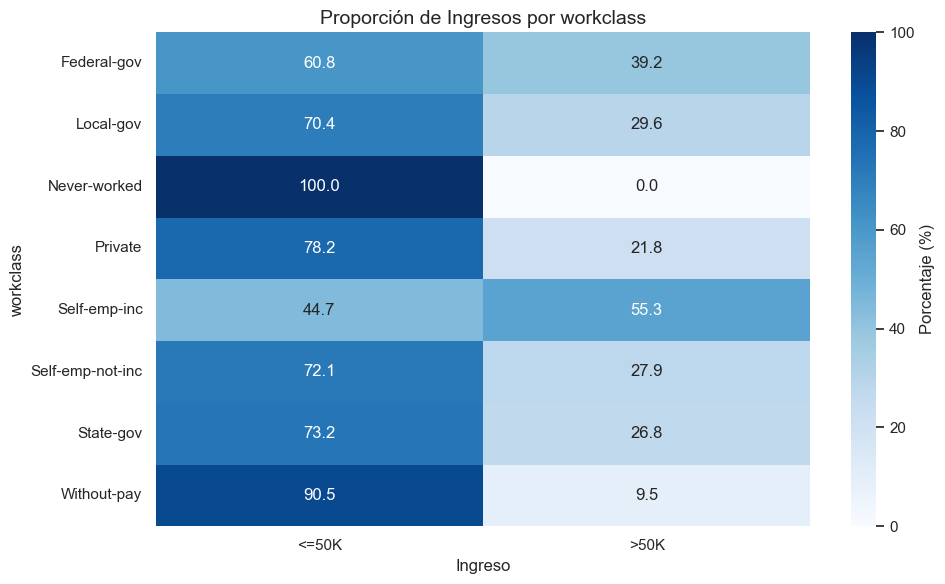

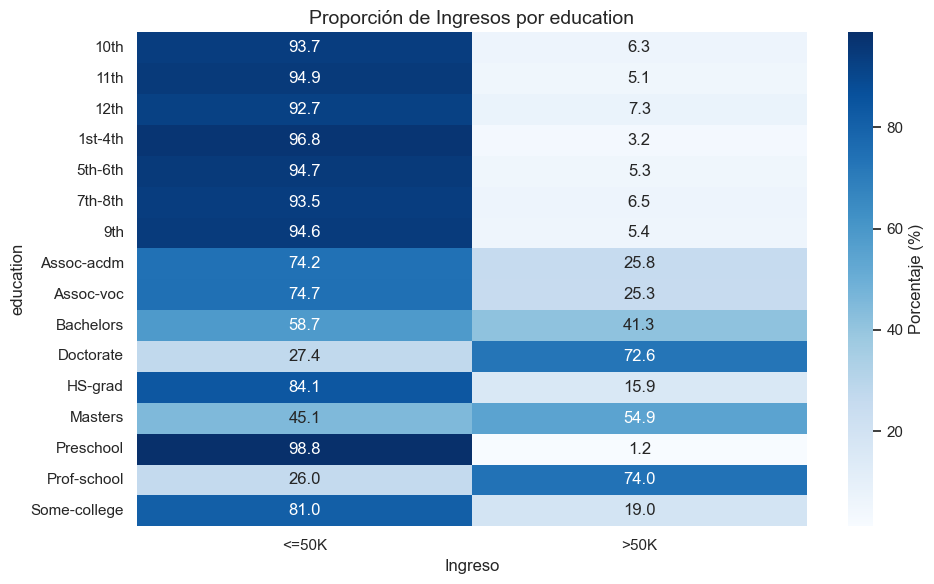

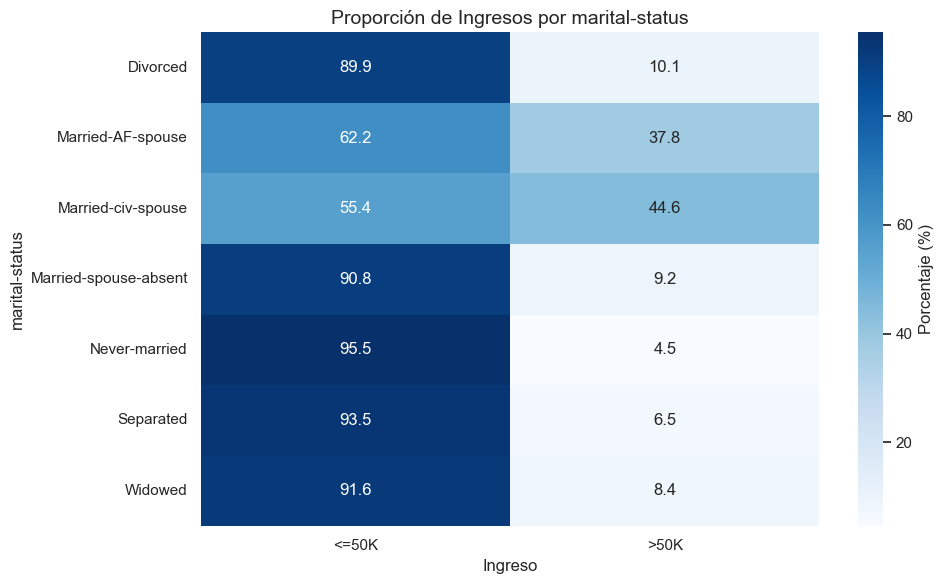

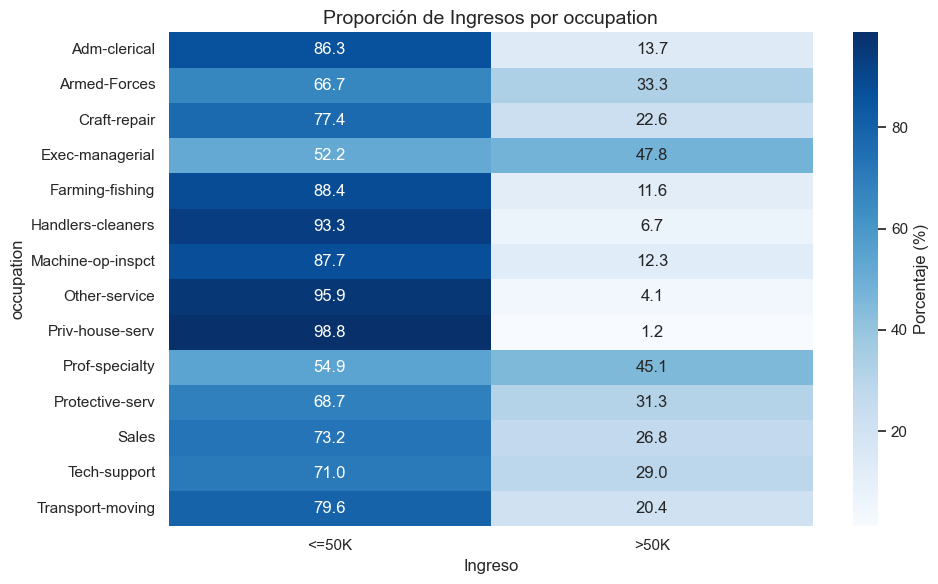

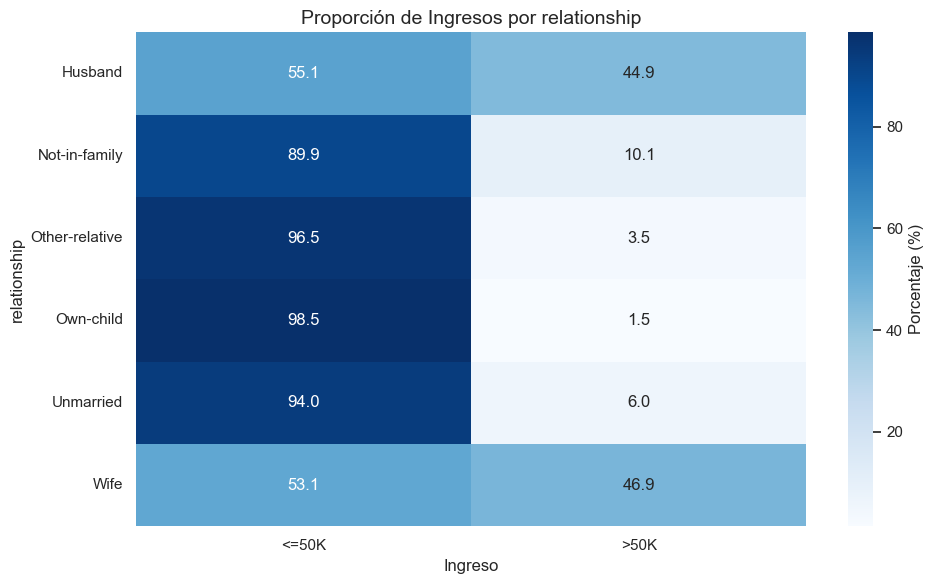

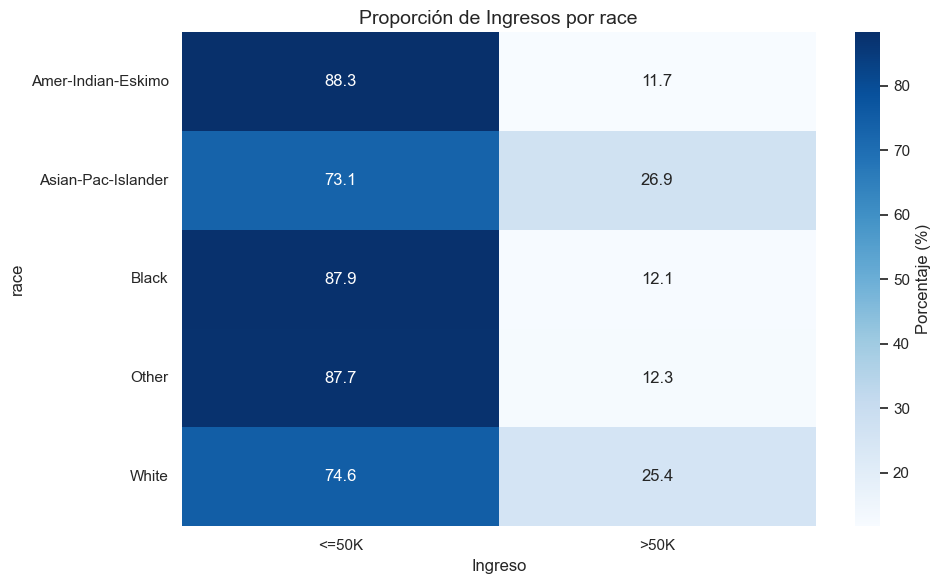

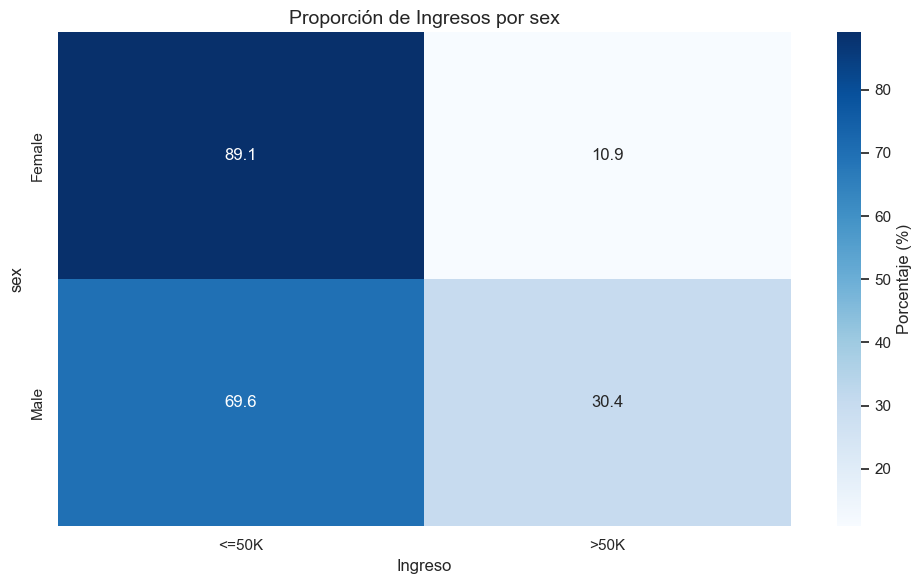

In [120]:
save_dir = Path("plots/tablas_variables")
save_dir.mkdir(parents=True, exist_ok=True)

for var in nom_cols.drop(columns=['native-country']):
    plt.figure(figsize=(10, 6))
    
    # 1. Crear tabla de contingencia normalizada (índice = 100%)
    ct = pd.crosstab(df[var], df['income'], normalize='index') * 100
    
    # 2. Corregido: sns.heatmap no necesita .plot(), se le pasa la tabla directamente
    # 'fmt=".1f"' asegura que los números dentro del mapa de calor sean legibles
    sns.heatmap(ct, annot=True, fmt=".1f", cmap='Blues', cbar_kws={'label': 'Porcentaje (%)'})
    
    plt.title(f'Proporción de Ingresos por {var}', fontsize=14)
    plt.ylabel(var)
    plt.xlabel('Ingreso')
    plt.savefig(save_dir / f"{var}_tabla.png", dpi=400, bbox_inches='tight')
    
    # Ajuste de layout para evitar cortes
    plt.tight_layout()
    plt.show()

# Marital vs Relationship

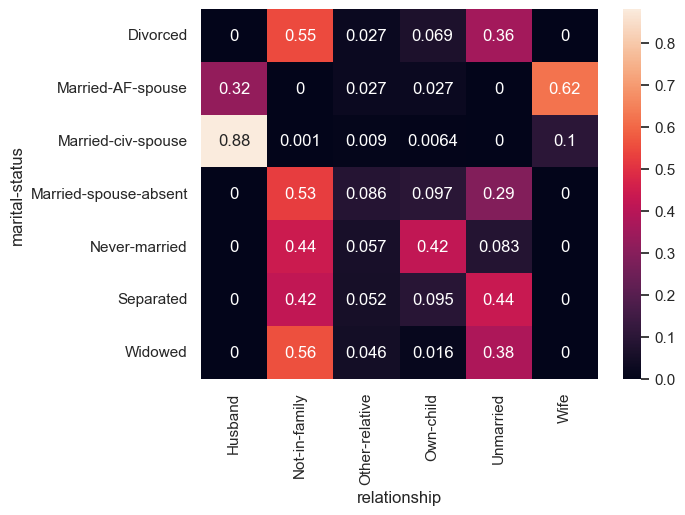

In [121]:
save_dir = Path("plots/correlaciones_variables")
save_dir.mkdir(parents=True, exist_ok=True)

mar_vs_rel = pd.crosstab(df['marital-status'],df['relationship'], normalize='index')
sns.heatmap(mar_vs_rel, annot=True)
plt.savefig(save_dir / f"marital_status_vs_relationship.png", dpi=400, bbox_inches='tight')
plt.show()

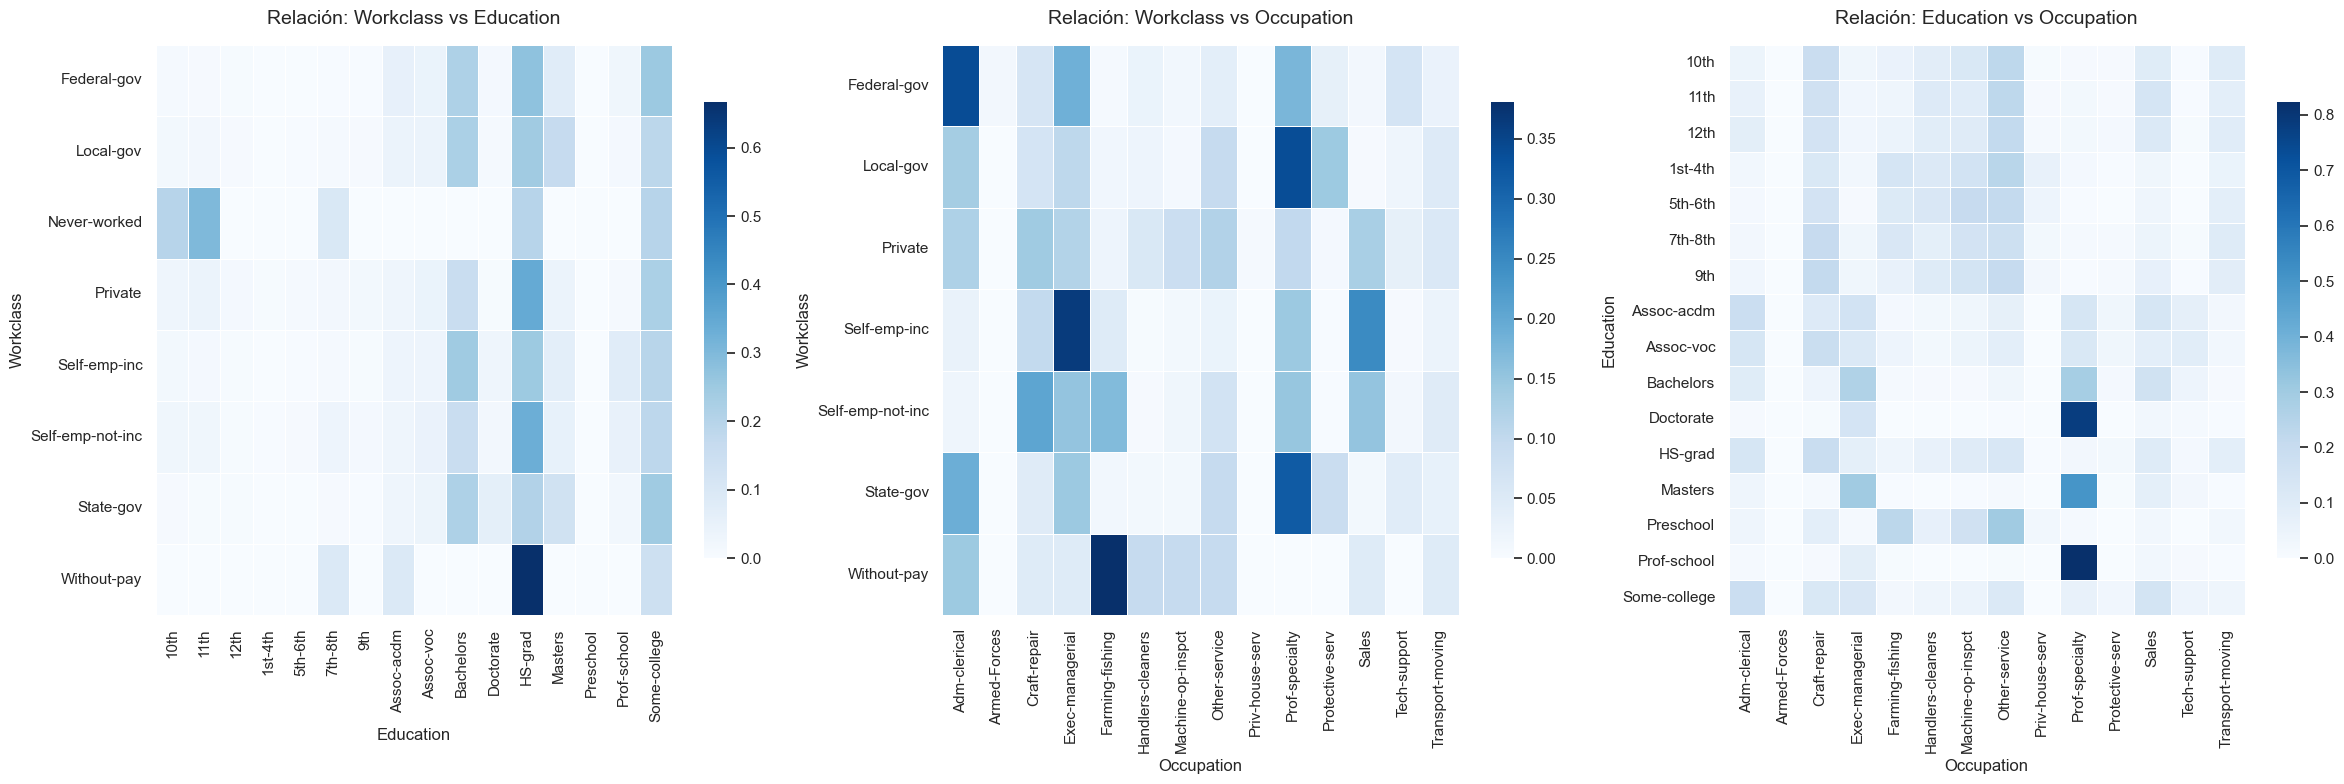

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# 3. Definimos los pares que vamos a cruzar
pares = [
    ('workclass', 'education'),   # Reemplaza 'education' por tu variable agrupada si deseas
    ('workclass', 'occupation'),
    ('education', 'occupation')
]

# 4. Bucle para generar cada mapa de calor
for i, (var_y, var_x) in enumerate(pares):
    # Calculamos la tabla cruzada normalizada por filas
    crosstab = pd.crosstab(df[var_y], df[var_x], normalize='index')

    sns.heatmap(crosstab, 
                annot=False, 
                cmap='Blues', 
                linewidths=0.5, 
                ax=axes[i], # Dibuja en el subplot
                cbar_kws={'shrink': 0.8})
    
    axes[i].set_title(f'Relación: {var_y.capitalize()} vs {var_x.capitalize()}', fontsize=14, pad=15)
    axes[i].set_ylabel(var_y.capitalize(), fontsize=12)
    axes[i].set_xlabel(var_x.capitalize(), fontsize=12)
    axes[i].tick_params(axis='x', rotation=90)
    

    fig_ind, ax_ind = plt.subplots(figsize=(16, 9))
    
    sns.heatmap(crosstab, 
                annot=False, 
                cmap='Blues', 
                linewidths=0.5, 
                ax=ax_ind,
                cbar_kws={'shrink': 0.8})
    
    ax_ind.set_title(f'Relación: {var_y.capitalize()} vs {var_x.capitalize()}', fontsize=14, pad=15)
    ax_ind.set_ylabel(var_y.capitalize(), fontsize=12)
    ax_ind.set_xlabel(var_x.capitalize(), fontsize=12)
    ax_ind.tick_params(axis='x', rotation=90)
    
    fig_ind.tight_layout()
    
    fig_ind.savefig(save_dir / f"{var_y}_{var_x}_correlacion.png", dpi=400)
    
    plt.close(fig_ind)

plt.tight_layout()
plt.show()

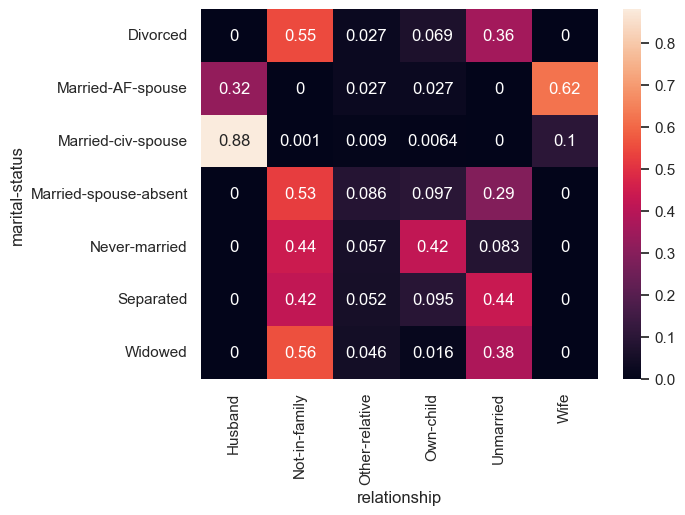

In [123]:
mar_vs_rel = pd.crosstab(df['marital-status'],df['relationship'], normalize='index')
sns.heatmap(mar_vs_rel, annot=True)
plt.show()

## Variables: capital-gain y capital-loss

### Gráfico inicial

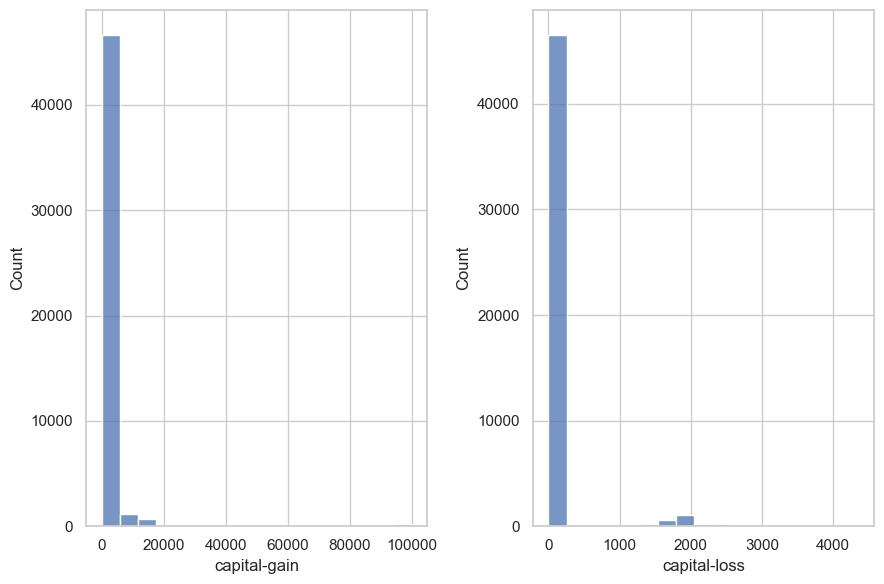

In [124]:
spec_col = ['capital-gain','capital-loss']
fig, axes = plt.subplots(1, 2, figsize=(9, 6))
axes = axes.flatten()
for c, ax in zip(spec_col, axes):
    sns.histplot(df[c], ax = ax)
plt.tight_layout()
plt.show()

### Aplicación de transformación logarítmica + 1 y filtro de valores

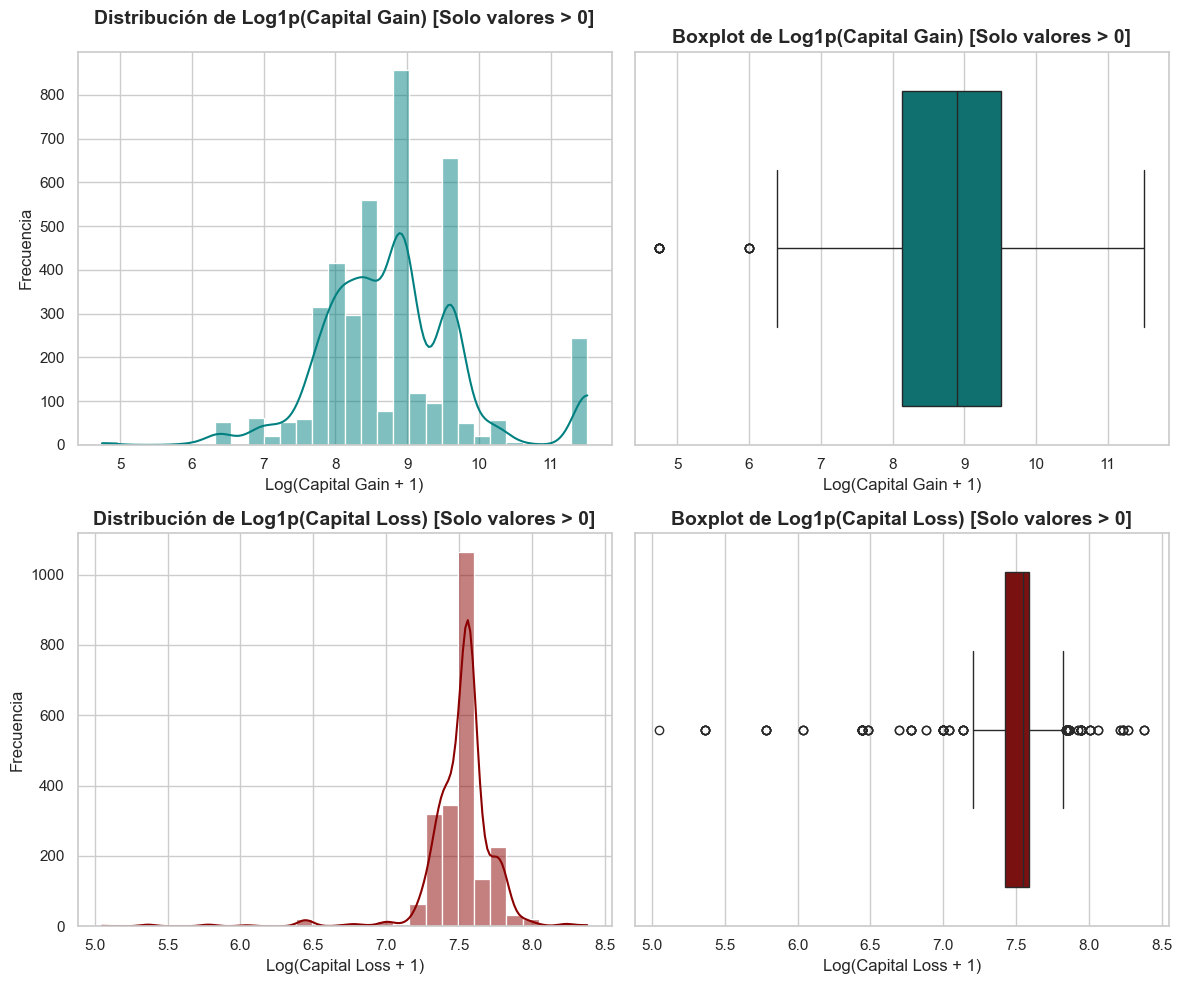

In [125]:
save_dir = Path("plots/capital_transformada")
save_dir.mkdir(parents=True, exist_ok=True)

spec_col = ['capital-gain','capital-loss','income']
df2 = df[spec_col]

log_gain_diferente_0 = np.log1p(df2[df2['capital-gain']>0]['capital-gain'])
log_loss_diferente_0 = np.log1p(df2[df2['capital-loss']>0]['capital-loss'])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(log_gain_diferente_0, bins=30, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribución de Log1p(Capital Gain) [Solo valores > 0]', fontsize=14, fontweight='bold', pad = 20)
axes[0, 0].set_xlabel('Log(Capital Gain + 1)')
axes[0, 0].set_ylabel('Frecuencia')

sns.boxplot(x=log_gain_diferente_0, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Boxplot de Log1p(Capital Gain) [Solo valores > 0]', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log(Capital Gain + 1)')

sns.histplot(log_loss_diferente_0, bins=30, kde=True, ax=axes[1, 0], color='darkred')
axes[1, 0].set_title('Distribución de Log1p(Capital Loss) [Solo valores > 0]', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Log(Capital Loss + 1)')
axes[1, 0].set_ylabel('Frecuencia')

sns.boxplot(x=log_loss_diferente_0, ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('Boxplot de Log1p(Capital Loss) [Solo valores > 0]', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Log(Capital Loss + 1)')

plt.tight_layout()
plt.savefig(save_dir / 'log1p_ganancias_perdidas_sin_0.png', dpi=400)
plt.show()

### Comprobación y transformación de variables

In [126]:
df[(df['capital-gain']>0)&(df['capital-loss']>0)] # Con este código observamos algo: No existen datos donde exista una ganancia y una pérdida a la vez

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income


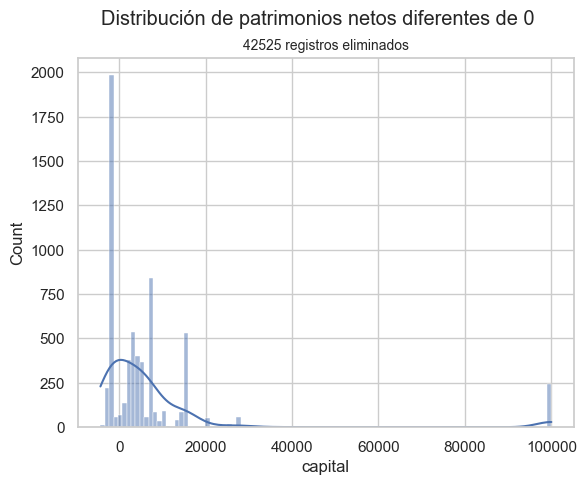

In [127]:
df2['capital'] = df2['capital-gain']-df2['capital-loss']
sns.histplot(df2[df2['capital']!=0]['capital'], kde=True)
plt.suptitle('Distribución de patrimonios netos diferentes de 0\n')
plt.title(f'{df2[df2['capital']==0]['capital'].count()} registros eliminados', fontsize = 10)
plt.show()

### Discretización de variables aplicando Árboles de Decisión

In [128]:
class DiscretizadorSupervisado(BaseEstimator, TransformerMixin):
    def __init__(self, max_depth=3, random_state=42):
        # Ya no pedimos las 'variables'. El ColumnTransformer se encargará de enviarlas.
        self.max_depth = max_depth
        self.random_state = random_state

    def fit(self, X, y=None):
        # 1. Validar que la variable objetivo (y) exista
        if y is None:
            raise ValueError("El DiscretizadorSupervisado requiere la variable objetivo 'y' durante el fit.")
            
        # 2. Convertir a DataFrame si el Pipeline nos pasa un Numpy Array
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        self.arboles_ = []
        
        # 3. Entrenar un árbol independiente por cada columna recibida
        for col in X.columns:
            arbol = DecisionTreeClassifier(max_depth=self.max_depth, random_state=self.random_state)
            arbol.fit(X[[col]], y)
            self.arboles_.append(arbol)
            
        return self

    def transform(self, X, y=None):
        # 1. Validar que el método fit ya fue ejecutado
        if not hasattr(self, "arboles_"):
            raise NotFittedError("Este transformador aún no ha sido entrenado (fit).")
            
        # 2. Asegurar formato DataFrame
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        X_copy = X.copy()
        
        # 3. Reemplazar los valores crudos por las probabilidades predecidas (la discretización)
        for i, col in enumerate(X.columns):
            # Extraemos la probabilidad de pertenecer a la clase 1 (>50K)
            X_copy[col] = self.arboles_[i].predict_proba(X[[col]])[:, 1]
            
        # Convertimos de vuelta a numpy array para evitar problemas con el ColumnTransformer
        return X_copy.to_numpy()
    
class DiscretizadorCapital(BaseEstimator, TransformerMixin):
    def __init__(self, max_depth=3, random_state=42):
        self.max_depth = max_depth
        self.random_state = random_state

    def fit(self, X, y=None):
        self._disc = DiscretizadorSupervisado(self.max_depth, self.random_state)
        self._disc.fit(X[['capital-gain', 'capital-loss']], y)

        # Aprender mapeos prob → etiqueta con datos de entrenamiento
        proba = self._disc.transform(X[['capital-gain', 'capital-loss']])
        proba_df = pd.DataFrame(proba, columns=['capital-gain', 'capital-loss'])
        self.mapeos_ = {
            col: {v: f"Nivel_{i+1}" for i, v in enumerate(sorted(proba_df[col].unique()))}
            for col in ['capital-gain', 'capital-loss']
        }
        return self

    def transform(self, X, y=None):
        X_copy = X.copy().reset_index(drop=True)
        proba = self._disc.transform(X_copy[['capital-gain', 'capital-loss']])
        proba_df = pd.DataFrame(proba, columns=['capital-gain', 'capital-loss'])
        X_copy['cat_capital-gain'] = proba_df['capital-gain'].map(self.mapeos_['capital-gain'])
        X_copy['cat_capital-loss'] = proba_df['capital-loss'].map(self.mapeos_['capital-loss'])
        return X_copy.drop(columns=['capital-gain', 'capital-loss'])

In [129]:
discretizador = DiscretizadorSupervisado(max_depth=3, random_state=42)

target_mapping = {'<=50K': 0, '>50K': 1}
df['income_num'] = df['income'].str.strip().map(target_mapping)

df[['cat_capital-gain', 'cat_capital-loss']] = discretizador.fit_transform(
    df[['capital-gain', 'capital-loss']], 
    df['income_num'] # Pasamos la versión numérica
)

for col in ['cat_capital-gain', 'cat_capital-loss']:
    # Dense rank asigna 1 al valor más bajo, 2 al siguiente, etc.
    df[col] = df[col].rank(method='dense').astype(int)
    # Le añadimos un prefijo para que sea categórico
    df[col] = 'Grupo_' + df[col].astype(str)

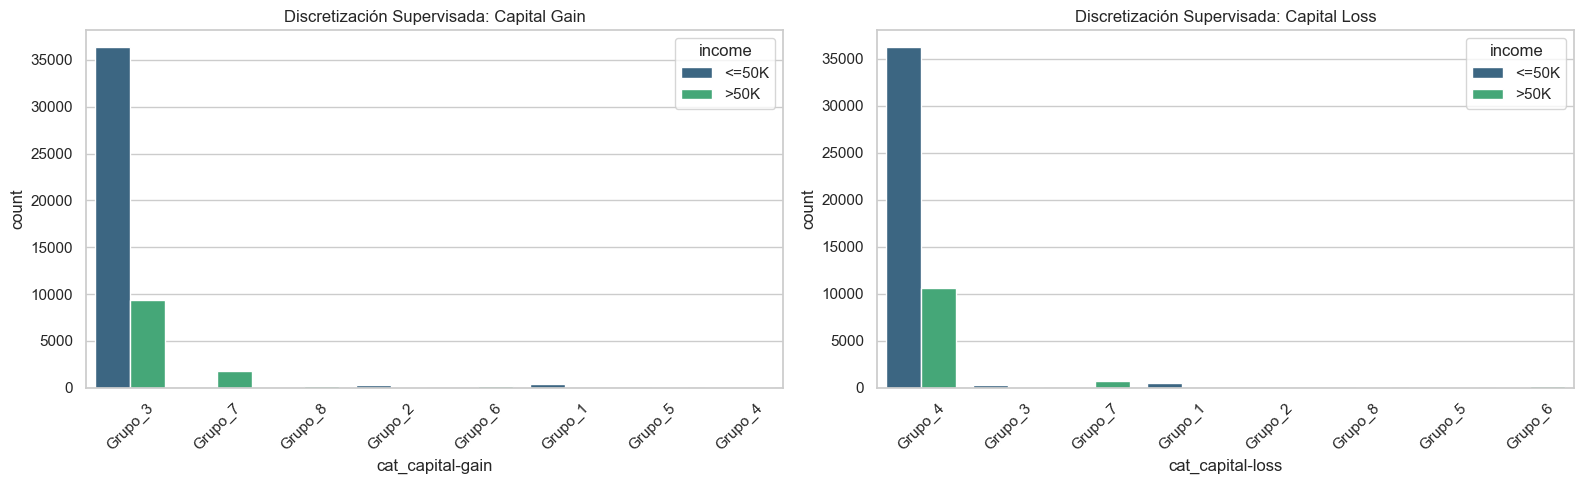

In [130]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x='cat_capital-gain', hue='income', ax=ax[0], palette='viridis')
ax[0].set_title('Discretización Supervisada: Capital Gain')
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='cat_capital-loss', hue='income', ax=ax[1], palette='viridis')
ax[1].set_title('Discretización Supervisada: Capital Loss')
ax[1].tick_params(axis='x', rotation=45)

plt.savefig(save_dir / 'discretizacion_supervisada.png', dpi=400)
plt.tight_layout()
plt.show()

Este método permite discretizar la variable de manera más profesional y exacta. Observamos que las secciona en 8 categorías.

---

## Correlaciones entre las variables numéricas

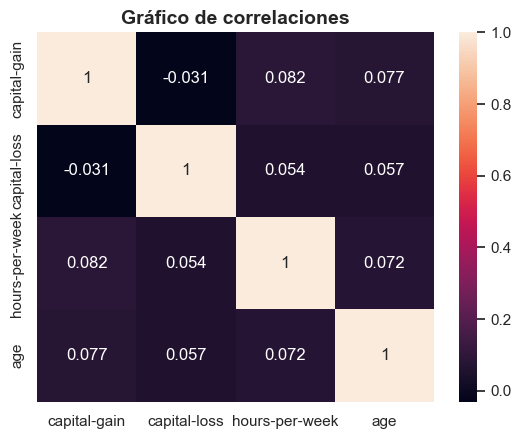

In [131]:
save_dir = Path("plots/correlaciones_variables")
save_dir.mkdir(parents=True, exist_ok=True)

corr = df[['capital-gain','capital-loss','hours-per-week','age']].corr()


sns.heatmap(corr, annot=True)
plt.title('Gráfico de correlaciones', fontweight='bold', fontsize = 14)
plt.savefig(save_dir / 'correlaciones_num.png', dpi=400, bbox_inches='tight')
plt.show()

Observamos que ninguna de las variables no están medianamente ni fuertemente correlacionadas entre si.